In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

from scipy import stats

In [ ]:
# ── Sensor config ──────────────────────────────────────────────
SENSOR_COLS   = ['temperature', 'temp_i2c', 'moisture_raw', 'light', 'humidity']
TIME_COL      = 'created_at'



In [ ]:
sensors_df = pd.read_csv('/content/drive/MyDrive/DA/sensors_da.csv')
sensors_df

,farm_id,lat,lon,moisture_raw,light,temperature,humidity,temp_i2c,created_at
0,1,13.845167,100.570103,3606,31.52,25,68,26.0625,2026-03-16 0:04:06
1,1,13.845167,100.570103,3609,32.55,25,68,26.0625,2026-03-16 0:09:06
2,1,13.845167,100.570103,3614,32.16,25,67,26.0938,2026-03-16 0:14:06
3,1,13.845167,100.570103,3618,31.52,25,68,26.3125,2026-03-16 0:19:06
4,1,13.845167,100.570103,3621,31.68,24,69,25.0312,2026-03-16 0:24:06
...,...,...,...,...,...,...,...,...,...
10403,1,13.845167,100.570103,3950,31.52,24,64,25.0625,2026-04-21 21:40:00
10404,1,13.845167,100.570103,3952,32.18,24,64,24.9375,2026-04-21 21:45:00
10405,1,13.845167,100.570103,3956,31.56,24,65,24.8750,2026-04-21 21:50:00
10406,1,13.845167,100.570103,3962,31.75,24,65,25.0000,2026-04-21 21:55:00


#Data Exploration

In [ ]:
sensors_df.shape

(10408, 9)

In [ ]:
sensors_df.dtypes

,0
farm_id,int64
lat,float64
lon,float64
moisture_raw,int64
light,float64
temperature,int64
humidity,int64
temp_i2c,float64
created_at,object


In [ ]:
sensors_df.describe()

,farm_id,lat,lon,moisture_raw,light,temperature,humidity,temp_i2c
count,10408.0,1.040800e+04,1.040800e+04,10408.000000,10408.000000,10408.000000,10408.000000,10408.000000
mean,1.0,1.384517e+01,1.005701e+02,4061.585031,404.758643,26.498751,59.719927,27.407307
std,0.0,2.181471e-12,1.227877e-11,86.400029,495.023929,1.584917,17.706062,2.065918
min,1.0,1.384517e+01,1.005701e+02,3557.000000,31.520000,23.000000,29.000000,23.000000
25%,1.0,1.384517e+01,1.005701e+02,4095.000000,32.060000,25.000000,42.000000,25.781200
50%,1.0,1.384517e+01,1.005701e+02,4095.000000,74.520000,26.000000,61.000000,26.968800
75%,1.0,1.384517e+01,1.005701e+02,4095.000000,713.980000,28.000000,73.000000,29.156200
max,1.0,1.384517e+01,1.005701e+02,4095.000000,1808.510000,31.000000,95.000000,33.218800


##checking missing sensor value

In [ ]:
missing_pct = sensors_df[SENSOR_COLS].isna().mean() * 100
print(missing_pct.round(2).to_string())

temperature     0.0
temp_i2c        0.0
moisture_raw    0.0
light           0.0
humidity        0.0


<Axes: >

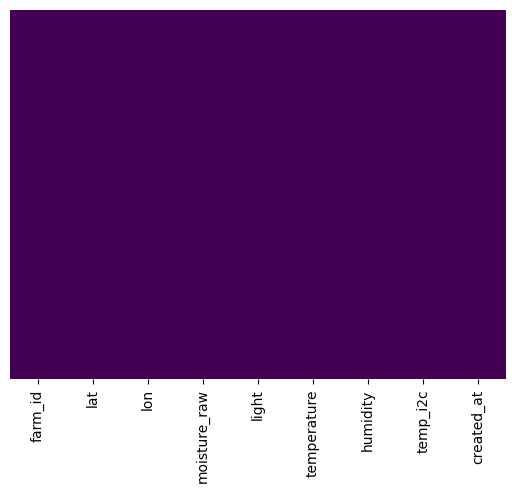

In [ ]:
sns.heatmap(sensors_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

No broken sensor midway

##Sensor selection:
Compares the two temperature sensors (temperature vs temp_i2c) using Pearson r, bias, MAE, and RMSE on daily Tmin/Tmax. Review the diurnal plot before setting TEMP_SOURCE.

In [ ]:
# Sensor timestamps are stored in UTC (device default). Shift to Bangkok (UTC+7)
# to align with Open-Meteo data fetched with timezone='Asia/Bangkok'.
sensors_df[TIME_COL] = pd.to_datetime(sensors_df[TIME_COL]) + pd.Timedelta(hours=7)
sensors_df['_hour']  = sensors_df[TIME_COL].dt.hour


hourly_profile = (
    sensors_df.groupby('_hour')[['temperature', 'temp_i2c']]
    .median()
    .reset_index()
)

# Noise proxy: std dev across all readings per sensor
noise = sensors_df[['temperature', 'temp_i2c']].std()
bias  = (sensors_df['temperature'] - sensors_df['temp_i2c']).mean()
print(f"Sensor comparison")
print(f"  Std dev  — temperature: {noise['temperature']:.3f}°C  |  temp_i2c: {noise['temp_i2c']:.3f}°C")
print(f"  Mean bias (temperature − temp_i2c): {bias:+.3f}°C")

Sensor comparison
  Std dev  — temperature: 1.585°C  |  temp_i2c: 2.066°C
  Mean bias (temperature − temp_i2c): -0.909°C


════════════════════════════════════════════════════
  DAY   (06–17)  n=5,156
    mean bias : +1.650°C
    std       : 0.480°C
    MAE       : 1.650°C
  NIGHT (18–05)  n=5,252
    mean bias : +0.181°C
    std       : 0.478°C
    MAE       : 0.402°C
════════════════════════════════════════════════════


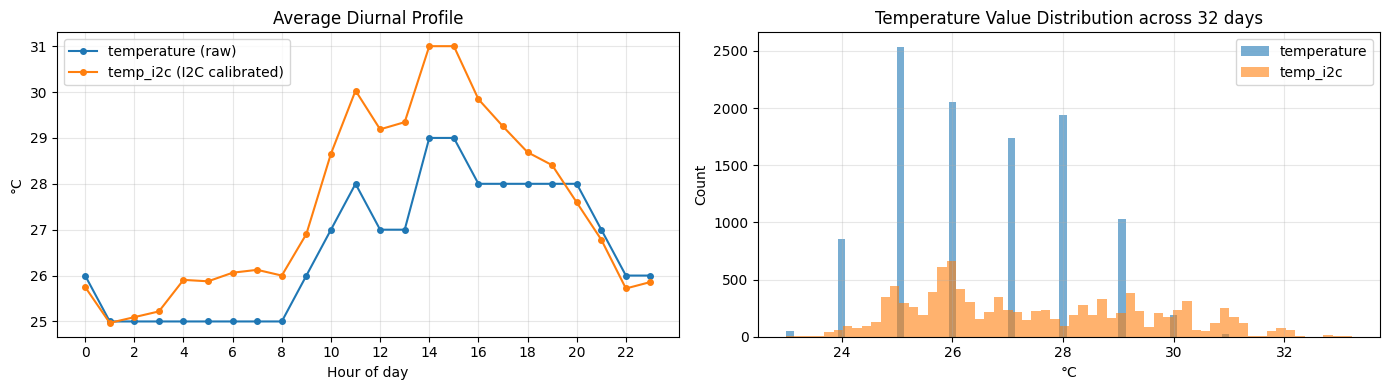

In [ ]:
cmp = sensors_df[['_hour', 'temperature', 'temp_i2c']].dropna().copy()
cmp['bias']   = cmp['temp_i2c'] - cmp['temperature']
cmp['is_day'] = cmp['_hour'].between(6, 17)

bias_by_hour = (
    cmp.groupby('_hour')['bias']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'bias_mean', 'std': 'bias_std'})
)

# ── Print stats DAY vs NIGHT ───────────────────────────────────
print('═' * 52)
for label, mask in [('DAY   (06–17)', cmp['is_day']),
                    ('NIGHT (18–05)', ~cmp['is_day'])]:
    sub = cmp[mask]['bias']
    print(f"  {label}  n={len(sub):,}")
    print(f"    mean bias : {sub.mean():+.3f}°C")
    print(f"    std       : {sub.std():.3f}°C")
    print(f"    MAE       : {sub.abs().mean():.3f}°C")
print('═' * 52)


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1 — average diurnal curve for both sensors
ax = axes[0]
ax.plot(hourly_profile['_hour'], hourly_profile['temperature'],
        marker='o', ms=4, label='temperature (raw)')
ax.plot(hourly_profile['_hour'], hourly_profile['temp_i2c'],
        marker='o', ms=4, label='temp_i2c (I2C calibrated)')
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel('Hour of day')
ax.set_ylabel('°C')
ax.set_title('Average Diurnal Profile')
ax.legend()
ax.grid(alpha=0.3)

# Panel 2 — distribution (histogram) of each sensor
ax = axes[1]
ax.hist(sensors_df['temperature'].dropna(), bins=60, alpha=0.6, label='temperature')
ax.hist(sensors_df['temp_i2c'].dropna(),    bins=60, alpha=0.6, label='temp_i2c')
ax.set_xlabel('°C')
ax.set_ylabel('Count')
ax.set_title('Temperature Value Distribution across 32 days')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


##Sensor decision


> ***temperature*** shows a suspicious flat plateau at night, indicating a calibration floor that inflates the hourly mean across the full day. Since GDD is calculated directly from hourly mean temperature, this artefact would systematically overestimate GDD. temp_i2c follows a natural diurnal curve without clamping and is therefore selected as the authoritative temperature source.

In [ ]:
TEMP_SOURCE = 'temp_i2c'
print(f"TEMP_SOURCE selected: '{TEMP_SOURCE}'")

TEMP_SOURCE selected: 'temp_i2c'


# Pre-processing

In [ ]:
# Floor timestamp to hour, then mean for temperature
sensors_df['hour'] = sensors_df['created_at'].dt.floor('h')
hourly_df = sensors_df.groupby('hour', as_index=False).agg({
    TEMP_SOURCE: 'mean',
})
hourly_df = hourly_df.rename(columns={'hour': 'timestamp', TEMP_SOURCE: 'sensor_temp'})
print(hourly_df.shape)
hourly_df.head()

(875, 2)


,timestamp,sensor_temp
0,2026-03-16 07:00:00,25.895833
1,2026-03-16 08:00:00,25.307283
2,2026-03-16 09:00:00,26.734367
3,2026-03-16 10:00:00,28.276033
4,2026-03-16 11:00:00,29.432300


In [ ]:
# Complete hourly index from first to last
full_idx = pd.date_range(hourly_df['timestamp'].min(),
                         hourly_df['timestamp'].max(),
                         freq='h')

hourly_df = hourly_df.set_index('timestamp').reindex(full_idx).rename_axis('timestamp').reset_index()

# Identify gap runs
hourly_df['is_missing'] = hourly_df['sensor_temp'].isna()
hourly_df['gap_group'] = (hourly_df['is_missing'] != hourly_df['is_missing'].shift()).cumsum()
gap_sizes = hourly_df[hourly_df['is_missing']].groupby('gap_group').size()
print("Gap sizes (hours) count:")
print(gap_sizes.value_counts().sort_index())

Gap sizes (hours) count:
1    2
2    1
4    2
Name: count, dtype: int64


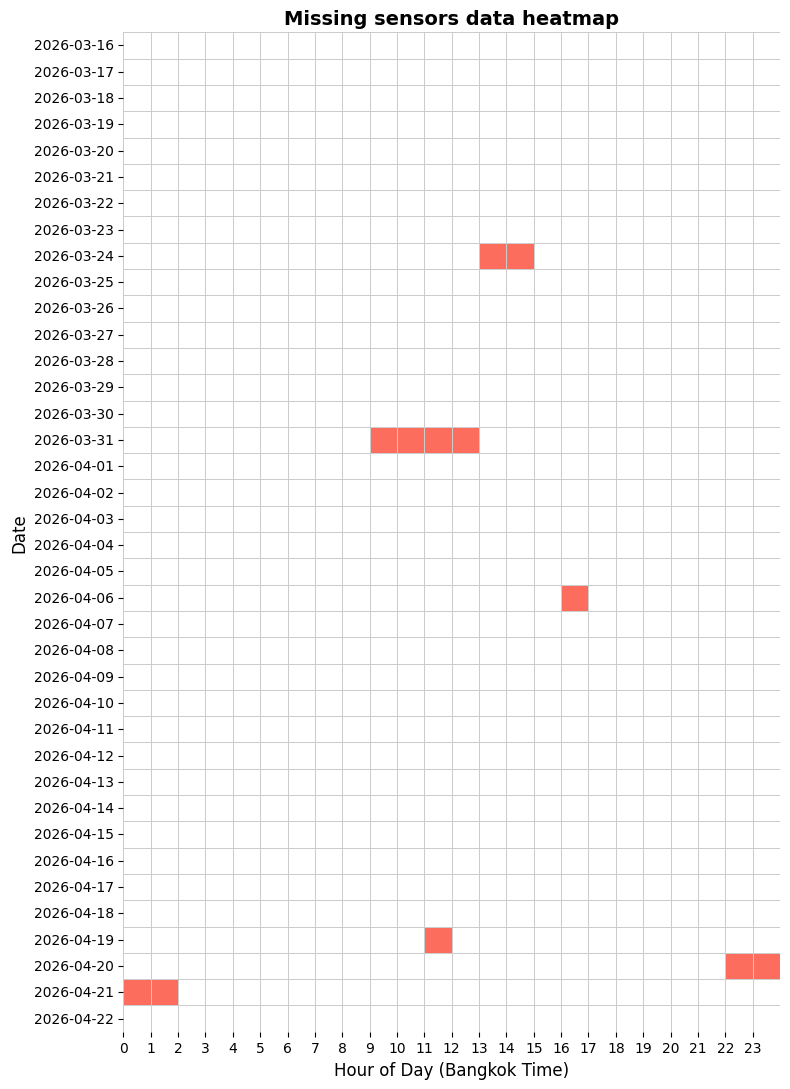

In [ ]:
def plot_hourly_data_continuity(df, name):
  # Create a full hourly range
  full_range = pd.date_range(
      start=df[TIME_COL].min().floor('h'),
      end=df[TIME_COL].max().ceil('h'),
      freq='h'
  )

  # Calculate counts and create a pivot table (Date vs Hour)
  status_df = pd.DataFrame(index=full_range)
  status_df['count'] = df.groupby(df[TIME_COL].dt.floor('h')).size().reindex(full_range, fill_value=0)
  status_df['date'] = status_df.index.date
  status_df['hour'] = status_df.index.hour

  # 0 = Missing, 1 = Has Data
  status_df['is_present'] = (status_df['count'] > 0).astype(int)
  pivot_status = status_df.pivot(index='date', columns='hour', values='is_present')

  plt.figure(figsize=(8, 11))
  sns.heatmap(pivot_status, cmap=['#fc6d5d', '#ffffff'], cbar=False, linewidths=0.5, linecolor='#cccccc')

  plt.title(name, fontsize=14, fontweight='bold')
  plt.ylabel('Date', fontsize=12)
  plt.xlabel('Hour of Day (Bangkok Time)', fontsize=12)

  # Formatting labels
  plt.xticks(ticks=np.arange(0, 24, 1), labels=np.arange(0, 24, 1), rotation=0)
  plt.tight_layout()
  plt.show()

plot_hourly_data_continuity(sensors_df, "Missing sensors data heatmap")

Still missing after imputation: 8
(879, 2)


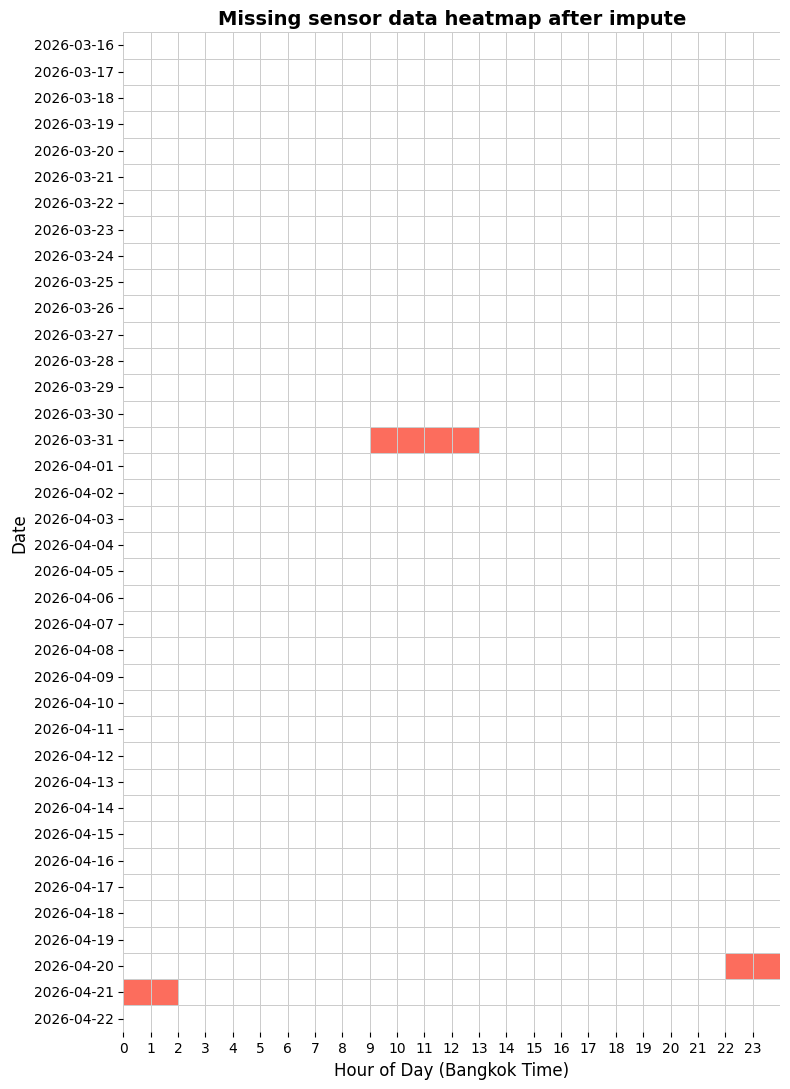

In [ ]:
# Short gaps: fill with median of same hour-of-day from ±3 days around the gap
def impute_short_gap(df, max_gap_hours=3, window_days=3):
    df = df.copy()
    df['hour_of_day'] = df['timestamp'].dt.hour
    for gid, gdf in df[df['is_missing']].groupby('gap_group'):
        if len(gdf) > max_gap_hours:
            continue
        for idx, row in gdf.iterrows():
            target_hour = row['hour_of_day']
            target_ts = row['timestamp']
            window_start = target_ts - pd.Timedelta(days=window_days)
            window_end   = target_ts + pd.Timedelta(days=window_days)
            mask = (
                (df['timestamp'] >= window_start) &
                (df['timestamp'] <= window_end) &
                (df['hour_of_day'] == target_hour) &
                (~df['sensor_temp'].isna())
            )
            if mask.any():
                df.at[idx, 'sensor_temp'] = df.loc[mask, 'sensor_temp'].median()
    return df

hourly_df = impute_short_gap(hourly_df)

# Drop rows that are still NaN (the long gaps)
print(f"Still missing after imputation: {hourly_df['sensor_temp'].isna().sum()}")
hourly_df = hourly_df.dropna(subset=['sensor_temp']).reset_index(drop=True)
hourly_df = hourly_df[['timestamp', 'sensor_temp']]
print(hourly_df.shape)

tmp_df = hourly_df.copy()
tmp_df['created_at'] = tmp_df['timestamp']
plot_hourly_data_continuity(tmp_df, "Missing sensor data heatmap after impute")

### weather forecast fetched from Open Meteo

In [ ]:
# !pip install openmeteo-requests
# !pip install requests-cache retry-requests numpy pandas

In [ ]:
# import openmeteo_requests

# import pandas as pd
# import requests_cache
# from retry_requests import retry

# # Setup the Open-Meteo API client with cache and retry on error
# cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
# retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
# openmeteo = openmeteo_requests.Client(session = retry_session)

# # Make sure all required weather variables are listed here
# # The order of variables in hourly or daily is important to assign them correctly below
# url = "https://previous-runs-api.open-meteo.com/v1/forecast"
# params = {
# 	"latitude": 13.845167,
# 	"longitude": 100.570103,
# 	"hourly": ["temperature_2m_previous_day1", "temperature_2m_previous_day2", "temperature_2m_previous_day3", "temperature_2m_previous_day4", "temperature_2m_previous_day5", "temperature_2m_previous_day6", "temperature_2m_previous_day7", "relative_humidity_2m_previous_day1", "relative_humidity_2m_previous_day2", "relative_humidity_2m_previous_day3", "relative_humidity_2m_previous_day4", "relative_humidity_2m_previous_day5", "relative_humidity_2m_previous_day6", "relative_humidity_2m_previous_day7", "shortwave_radiation_previous_day1", "shortwave_radiation_previous_day2", "shortwave_radiation_previous_day3", "shortwave_radiation_previous_day4", "shortwave_radiation_previous_day5", "shortwave_radiation_previous_day6", "shortwave_radiation_previous_day7"],
# 	"models": "best_match",
# 	"timezone": "Asia/Bangkok",
# 	"start_date": "2026-03-08",
# 	"end_date": "2026-04-29",
# 	"temporal_resolution": "native",
# }
# responses = openmeteo.weather_api(url, params = params)

# # Process first location. Add a for-loop for multiple locations or weather models
# response = responses[0]
# print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
# print(f"Elevation: {response.Elevation()} m asl")
# print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
# print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# # Process hourly data. The order of variables needs to be the same as requested.
# hourly = response.Hourly()
# hourly_temperature_2m_previous_day1 = hourly.Variables(0).ValuesAsNumpy()
# hourly_temperature_2m_previous_day2 = hourly.Variables(1).ValuesAsNumpy()
# hourly_temperature_2m_previous_day3 = hourly.Variables(2).ValuesAsNumpy()
# hourly_temperature_2m_previous_day4 = hourly.Variables(3).ValuesAsNumpy()
# hourly_temperature_2m_previous_day5 = hourly.Variables(4).ValuesAsNumpy()
# hourly_temperature_2m_previous_day6 = hourly.Variables(5).ValuesAsNumpy()
# hourly_temperature_2m_previous_day7 = hourly.Variables(6).ValuesAsNumpy()
# hourly_relative_humidity_2m_previous_day1 = hourly.Variables(7).ValuesAsNumpy()
# hourly_relative_humidity_2m_previous_day2 = hourly.Variables(8).ValuesAsNumpy()
# hourly_relative_humidity_2m_previous_day3 = hourly.Variables(9).ValuesAsNumpy()
# hourly_relative_humidity_2m_previous_day4 = hourly.Variables(10).ValuesAsNumpy()
# hourly_relative_humidity_2m_previous_day5 = hourly.Variables(11).ValuesAsNumpy()
# hourly_relative_humidity_2m_previous_day6 = hourly.Variables(12).ValuesAsNumpy()
# hourly_relative_humidity_2m_previous_day7 = hourly.Variables(13).ValuesAsNumpy()
# # hourly_shortwave_radiation_previous_day1 = hourly.Variables(14).ValuesAsNumpy()
# # hourly_shortwave_radiation_previous_day2 = hourly.Variables(15).ValuesAsNumpy()
# # hourly_shortwave_radiation_previous_day3 = hourly.Variables(16).ValuesAsNumpy()
# # hourly_shortwave_radiation_previous_day4 = hourly.Variables(17).ValuesAsNumpy()
# # hourly_shortwave_radiation_previous_day5 = hourly.Variables(18).ValuesAsNumpy()
# # hourly_shortwave_radiation_previous_day6 = hourly.Variables(19).ValuesAsNumpy()
# # hourly_shortwave_radiation_previous_day7 = hourly.Variables(20).ValuesAsNumpy()

# hourly_data = {"date": pd.date_range(
# 	start = pd.to_datetime(hourly.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
# 	end =  pd.to_datetime(hourly.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
# 	freq = pd.Timedelta(seconds = hourly.Interval()),
# 	inclusive = "left"
# )}

# hourly_data["temperature_2m_previous_day1"] = hourly_temperature_2m_previous_day1
# hourly_data["temperature_2m_previous_day2"] = hourly_temperature_2m_previous_day2
# hourly_data["temperature_2m_previous_day3"] = hourly_temperature_2m_previous_day3
# hourly_data["temperature_2m_previous_day4"] = hourly_temperature_2m_previous_day4
# hourly_data["temperature_2m_previous_day5"] = hourly_temperature_2m_previous_day5
# hourly_data["temperature_2m_previous_day6"] = hourly_temperature_2m_previous_day6
# hourly_data["temperature_2m_previous_day7"] = hourly_temperature_2m_previous_day7
# hourly_data["relative_humidity_2m_previous_day1"] = hourly_relative_humidity_2m_previous_day1
# hourly_data["relative_humidity_2m_previous_day2"] = hourly_relative_humidity_2m_previous_day2
# hourly_data["relative_humidity_2m_previous_day3"] = hourly_relative_humidity_2m_previous_day3
# hourly_data["relative_humidity_2m_previous_day4"] = hourly_relative_humidity_2m_previous_day4
# hourly_data["relative_humidity_2m_previous_day5"] = hourly_relative_humidity_2m_previous_day5
# hourly_data["relative_humidity_2m_previous_day6"] = hourly_relative_humidity_2m_previous_day6
# hourly_data["relative_humidity_2m_previous_day7"] = hourly_relative_humidity_2m_previous_day7
# # hourly_data["shortwave_radiation_previous_day1"] = hourly_shortwave_radiation_previous_day1
# # hourly_data["shortwave_radiation_previous_day2"] = hourly_shortwave_radiation_previous_day2
# # hourly_data["shortwave_radiation_previous_day3"] = hourly_shortwave_radiation_previous_day3
# # hourly_data["shortwave_radiation_previous_day4"] = hourly_shortwave_radiation_previous_day4
# # hourly_data["shortwave_radiation_previous_day5"] = hourly_shortwave_radiation_previous_day5
# # hourly_data["shortwave_radiation_previous_day6"] = hourly_shortwave_radiation_previous_day6
# # hourly_data["shortwave_radiation_previous_day7"] = hourly_shortwave_radiation_previous_day7

# hourly_weather_df = pd.DataFrame(data = hourly_data)
# hourly_weather_df

# # Save the fetched weather data to Google Drive
# output_path = '/content/drive/MyDrive/DA/OM_forecast.csv'
# hourly_weather_df.to_csv(output_path, index=False)
# print(f"Successfully saved weather data to: {output_path}")

hourly_weather_df = pd.read_csv('/content/drive/MyDrive/DA/OM_forecast.csv')
hourly_weather_df

,date,temperature_2m_previous_day1,temperature_2m_previous_day2,temperature_2m_previous_day3,temperature_2m_previous_day4,temperature_2m_previous_day5,temperature_2m_previous_day6,temperature_2m_previous_day7,relative_humidity_2m_previous_day1,relative_humidity_2m_previous_day2,relative_humidity_2m_previous_day3,relative_humidity_2m_previous_day4,relative_humidity_2m_previous_day5,relative_humidity_2m_previous_day6,relative_humidity_2m_previous_day7
0,2026-03-08 00:00:00+00:00,30.20,29.90,30.10,29.60,26.45,28.55,28.15,52.295810,57.309628,60.059532,66.299614,92.860535,77.822716,71.239340
1,2026-03-08 01:00:00+00:00,29.05,28.95,29.25,29.05,28.20,28.05,27.70,65.785790,74.011604,56.100900,62.836700,82.324234,82.060930,72.470360
2,2026-03-08 02:00:00+00:00,28.55,28.40,28.30,28.60,27.80,27.55,27.15,72.398640,79.926680,60.766148,64.102560,84.771065,86.018875,74.388280
3,2026-03-08 03:00:00+00:00,28.35,28.05,27.80,28.20,27.45,26.90,26.40,70.843930,82.306435,64.129420,65.209160,86.266160,90.432274,77.272460
4,2026-03-08 04:00:00+00:00,27.90,27.55,27.20,27.80,27.10,26.30,25.65,68.215950,82.000570,68.288826,66.339140,87.269714,94.526130,80.287870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,2026-04-29 19:00:00+00:00,31.70,31.70,31.70,31.05,31.10,32.40,31.30,62.838420,62.838420,62.838420,67.800160,69.658390,52.687660,65.847176
1268,2026-04-29 20:00:00+00:00,31.00,31.00,31.00,30.45,30.55,31.75,30.80,67.993760,67.993760,67.993760,72.509910,73.396170,57.396790,68.980690
1269,2026-04-29 21:00:00+00:00,30.65,30.65,30.65,30.20,30.20,31.15,30.45,71.898780,71.898780,71.898780,75.778915,76.457000,62.530270,71.222560
1270,2026-04-29 22:00:00+00:00,30.35,30.35,30.35,29.95,29.95,30.65,30.25,75.129906,75.129906,75.129906,78.721054,78.488150,67.722200,72.692154


In [ ]:
# Rename timestamp column for consistency
df_om_wide = hourly_weather_df.rename(columns={'date': 'timestamp'})
df_om_wide['timestamp'] = pd.to_datetime(df_om_wide['timestamp'])

# Strip timezone info only if it has one (handles both fresh fetch and CSV reload)
if df_om_wide['timestamp'].dt.tz is not None:
    df_om_wide['timestamp'] = df_om_wide['timestamp'].dt.tz_localize(None)

# Reshape wide → long
frames = []
for h in range(1, 8):
    sub = df_om_wide[['timestamp',
        f'temperature_2m_previous_day{h}',
        f'relative_humidity_2m_previous_day{h}',
    ]].copy()
    sub.columns = ['timestamp',
                   'om_temp',
                   'om_humidity'
                   ]
    sub['horizon'] = h
    frames.append(sub)

df_om_long = pd.concat(frames, ignore_index=True)
print(df_om_long.shape)
df_om_long.head()

(8904, 4)


,timestamp,om_temp,om_humidity,horizon
0,2026-03-08 00:00:00,30.20,52.29581,1
1,2026-03-08 01:00:00,29.05,65.78579,1
2,2026-03-08 02:00:00,28.55,72.39864,1
3,2026-03-08 03:00:00,28.35,70.84393,1
4,2026-03-08 04:00:00,27.90,68.21595,1


### Merge sensors data with 7-day weather forecast from Open Meteo

In [ ]:
# Merge all sensor data (including temperature and humidity) with forecast data
df = hourly_df.merge(df_om_long, on='timestamp', how='inner')
print(f"Merged shape: {df.shape}")
print("Columns available:", df.columns.tolist())
df.head()

Merged shape: (6153, 5)
Columns available: ['timestamp', 'sensor_temp', 'om_temp', 'om_humidity', 'horizon']


,timestamp,sensor_temp,om_temp,om_humidity,horizon
0,2026-03-16 07:00:00,25.895833,26.95,68.873400,1
1,2026-03-16 07:00:00,25.895833,27.25,66.022750,2
2,2026-03-16 07:00:00,25.895833,27.15,75.757996,3
3,2026-03-16 07:00:00,25.895833,25.45,83.503490,4
4,2026-03-16 07:00:00,25.895833,27.05,77.839460,5


In [ ]:
# Cyclic hour encoding
df['hour_of_day'] = df['timestamp'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)


# # Cyclic doy encoding
# Result: Causing severe overfitting
# df['day_of_year'] = df['timestamp'].dt.dayofyear
# df['doy_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
# df['doy_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)

# # Cyclic month encoding
# Result: Causing severe overfitting
# df['month_of_year'] = df['timestamp'].dt.month
# df['month_sin'] = np.sin(2 * np.pi * df['month_of_year'] / 24)
# df['month_cos'] = np.cos(2 * np.pi * df['month_of_year'] / 24)

# Residual target
df['residual'] = df['sensor_temp'] - df['om_temp']

df = df.drop(columns=['hour_of_day'], errors='ignore')

print(df.columns.tolist())
df.head()

['timestamp', 'sensor_temp', 'om_temp', 'om_humidity', 'horizon', 'hour_sin', 'hour_cos', 'residual']


,timestamp,sensor_temp,om_temp,om_humidity,horizon,hour_sin,hour_cos,residual
0,2026-03-16 07:00:00,25.895833,26.95,68.873400,1,0.965926,-0.258819,-1.054167
1,2026-03-16 07:00:00,25.895833,27.25,66.022750,2,0.965926,-0.258819,-1.354167
2,2026-03-16 07:00:00,25.895833,27.15,75.757996,3,0.965926,-0.258819,-1.254167
3,2026-03-16 07:00:00,25.895833,25.45,83.503490,4,0.965926,-0.258819,0.445833
4,2026-03-16 07:00:00,25.895833,27.05,77.839460,5,0.965926,-0.258819,-1.154167


In [ ]:
# Split data into train/test using the updated dataframe with humidity
cutoff = df['timestamp'].max() - pd.Timedelta(days=7)

df_train = df[df['timestamp'] <  cutoff].reset_index(drop=True)
df_test  = df[df['timestamp'] >= cutoff].reset_index(drop=True)

print(f"Train size: {len(df_train)}, Test size: {len(df_test)}")

Train size: 4998, Test size: 1155


In [ ]:
df_train

,timestamp,sensor_temp,om_temp,om_humidity,horizon,hour_sin,hour_cos,residual
0,2026-03-16 07:00:00,25.895833,26.95,68.873400,1,0.965926,-0.258819,-1.054167
1,2026-03-16 07:00:00,25.895833,27.25,66.022750,2,0.965926,-0.258819,-1.354167
2,2026-03-16 07:00:00,25.895833,27.15,75.757996,3,0.965926,-0.258819,-1.254167
3,2026-03-16 07:00:00,25.895833,25.45,83.503490,4,0.965926,-0.258819,0.445833
4,2026-03-16 07:00:00,25.895833,27.05,77.839460,5,0.965926,-0.258819,-1.154167
...,...,...,...,...,...,...,...,...
4993,2026-04-15 04:00:00,24.950533,29.25,78.623380,3,0.866025,0.500000,-4.299467
4994,2026-04-15 04:00:00,24.950533,29.45,78.885510,4,0.866025,0.500000,-4.499467
4995,2026-04-15 04:00:00,24.950533,29.45,76.799870,5,0.866025,0.500000,-4.499467
4996,2026-04-15 04:00:00,24.950533,28.90,81.919270,6,0.866025,0.500000,-3.949467


# Modeling


* Ridge + actual temp (7 models, one per horizon)
* Ridge + residual (7 models, one per horizon)
* XGBoost + actual temp (1 pooled model)
* XGBoost + residual (1 pooled model)

## Train Test splitting

In [ ]:
from sklearn.preprocessing import StandardScaler

# Updated Features for Ridge
ridge_features = ['om_temp','om_humidity','hour_sin', 'hour_cos']

# Updated Features for XGBoost (horizon included)
xgb_features = ridge_features + ['horizon']

# # Scale features
scaler = StandardScaler()
scaler.fit(df_train[ridge_features])

df_train_scaled = df_train.copy()
df_test_scaled  = df_test.copy()
df_train_scaled[ridge_features] = scaler.transform(df_train[ridge_features])
df_test_scaled[ridge_features]  = scaler.transform(df_test[ridge_features])

df_train_scaled.head()

,timestamp,sensor_temp,om_temp,om_humidity,horizon,hour_sin,hour_cos,residual
0,2026-03-16 07:00:00,25.895833,-1.337586,0.296414,1,1.372374,-0.372661,-1.054167
1,2026-03-16 07:00:00,25.895833,-1.242382,0.133740,2,1.372374,-0.372661,-1.354167
2,2026-03-16 07:00:00,25.895833,-1.274117,0.689287,3,1.372374,-0.372661,-1.254167
3,2026-03-16 07:00:00,25.895833,-1.813602,1.131288,4,1.372374,-0.372661,0.445833
4,2026-03-16 07:00:00,25.895833,-1.305851,0.808067,5,1.372374,-0.372661,-1.154167


In [ ]:
df_train_scaled.isna().sum()

,0
timestamp,0
sensor_temp,0
om_temp,0
om_humidity,0
horizon,0
hour_sin,0
hour_cos,0
residual,0


### Ridge regression, predicting actual temp

In [ ]:
from sklearn.linear_model import Ridge

ridge_actual_models = {}
df_test_scaled['pred_ridge_actual'] = np.nan

for h in range(1, 8):
    train_h = df_train_scaled[df_train_scaled['horizon'] == h]
    test_h  = df_test_scaled[df_test_scaled['horizon'] == h]

    X_train = train_h[ridge_features]
    y_train = train_h['sensor_temp']

    model = Ridge(alpha=1.0).fit(X_train, y_train)
    ridge_actual_models[h] = model

    preds = model.predict(test_h[ridge_features])
    df_test_scaled.loc[df_test_scaled['horizon'] == h, 'pred_ridge_actual'] = preds

print(f"Trained {len(ridge_actual_models)} Ridge models (actual temp target)")
print(df_test_scaled[['timestamp', 'horizon', 'sensor_temp', 'pred_ridge_actual']].head(5))

Trained 7 Ridge models (actual temp target)
            timestamp  horizon  sensor_temp  pred_ridge_actual
0 2026-04-15 05:00:00        1    25.289058          25.293802
1 2026-04-15 05:00:00        2    25.289058          25.373316
2 2026-04-15 05:00:00        3    25.289058          25.392532
3 2026-04-15 05:00:00        4    25.289058          25.426938
4 2026-04-15 05:00:00        5    25.289058          25.448666


### Ridge regression, predicting residual

In [ ]:
ridge_residual_models = {}
df_test_scaled['pred_ridge_residual'] = np.nan

for h in range(1, 8):
    train_h = df_train_scaled[df_train_scaled['horizon'] == h]
    test_h  = df_test_scaled[df_test_scaled['horizon'] == h]

    X_train = train_h[ridge_features]
    y_train = train_h['residual']

    model = Ridge(alpha=1.0).fit(X_train, y_train)
    ridge_residual_models[h] = model

    pred_resid = model.predict(test_h[ridge_features])
    om_temp_orig = df_test.loc[df_test['horizon'] == h, 'om_temp'].values
    pred_temp = pred_resid + om_temp_orig
    df_test_scaled.loc[df_test_scaled['horizon'] == h, 'pred_ridge_residual'] = pred_temp

print(f"Trained {len(ridge_residual_models)} Ridge models (residual target)")
print(df_test_scaled[['timestamp', 'horizon', 'sensor_temp', 'pred_ridge_residual']].head(5))

Trained 7 Ridge models (residual target)
            timestamp  horizon  sensor_temp  pred_ridge_residual
0 2026-04-15 05:00:00        1    25.289058            25.311669
1 2026-04-15 05:00:00        2    25.289058            25.388354
2 2026-04-15 05:00:00        3    25.289058            25.405237
3 2026-04-15 05:00:00        4    25.289058            25.447111
4 2026-04-15 05:00:00        5    25.289058            25.458923


### XG Boost, predicting actual temp

In [ ]:
from xgboost import XGBRegressor

xgb_actual = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

X_train = df_train[xgb_features]
y_train = df_train['sensor_temp']
xgb_actual.fit(X_train, y_train)

X_test = df_test[xgb_features]
df_test_scaled['pred_xgb_actual'] = xgb_actual.predict(X_test)

print("XGBoost (actual temp) trained with updated features")
print(df_test_scaled[['timestamp', 'horizon', 'sensor_temp', 'pred_xgb_actual']].head(5))

XGBoost (actual temp) trained with updated features
            timestamp  horizon  sensor_temp  pred_xgb_actual
0 2026-04-15 05:00:00        1    25.289058        25.894564
1 2026-04-15 05:00:00        2    25.289058        25.258467
2 2026-04-15 05:00:00        3    25.289058        25.258467
3 2026-04-15 05:00:00        4    25.289058        25.258467
4 2026-04-15 05:00:00        5    25.289058        25.258467


### XG Boost, predicting residual

XGBoost (residual) retrained with features: ['om_temp', 'om_humidity', 'hour_sin', 'hour_cos', 'horizon']
            timestamp  horizon  sensor_temp  pred_xgb_residual
0 2026-04-15 05:00:00        1    25.289058          25.904897
1 2026-04-15 05:00:00        2    25.289058          25.357770
2 2026-04-15 05:00:00        3    25.289058          25.457770
3 2026-04-15 05:00:00        4    25.289058          25.507770
4 2026-04-15 05:00:00        5    25.289058          25.507770


/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


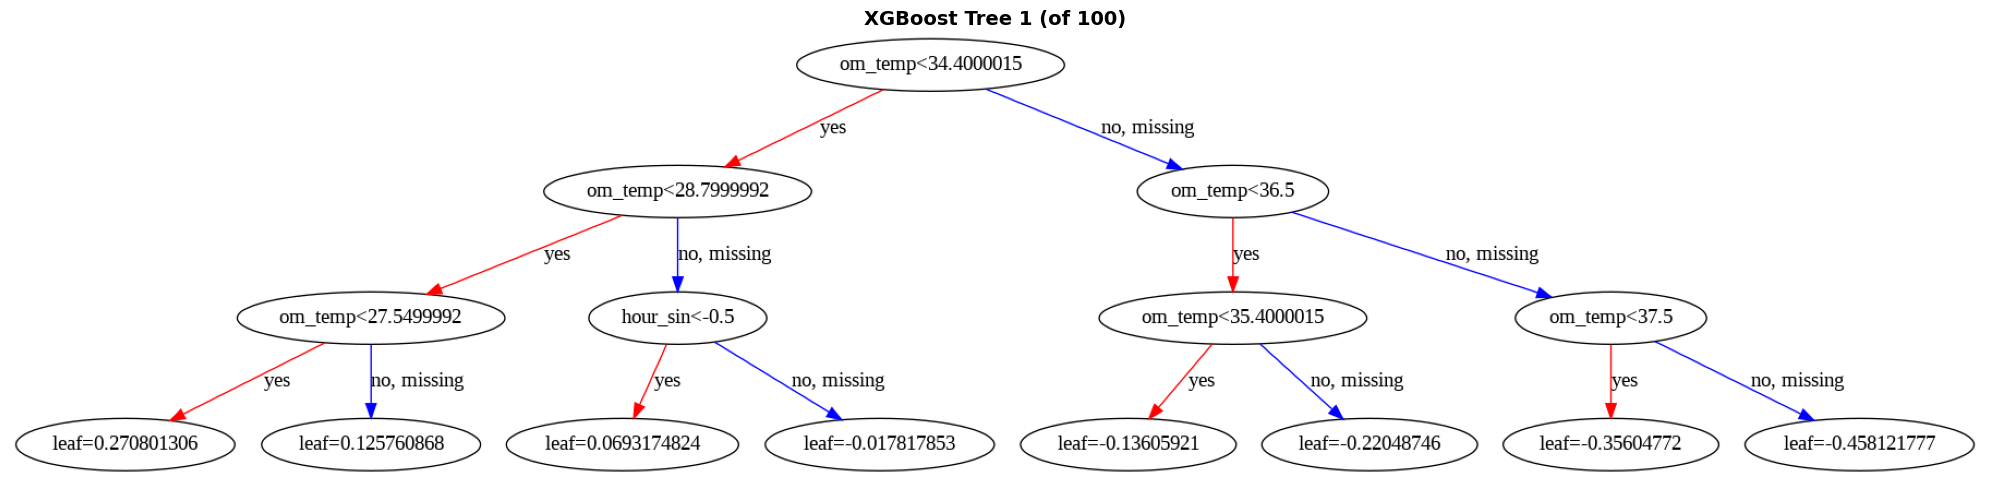

In [ ]:
xgb_residual = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

# Ensure we use the full feature set defined in xgb_features
X_train = df_train[xgb_features]
y_train = df_train['residual']
xgb_residual.fit(X_train, y_train)

pred_resid = xgb_residual.predict(df_test[xgb_features])
df_test_scaled['pred_xgb_residual'] = pred_resid + df_test['om_temp'].values

print(f"XGBoost (residual) retrained with features: {xgb_features}")
print(df_test_scaled[['timestamp', 'horizon', 'sensor_temp', 'pred_xgb_residual']].head(5))

from xgboost import plot_tree
import matplotlib.pyplot as plt

# Plot the first tree (tree index 0)
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(xgb_residual, num_trees=0, ax=ax)
plt.title('XGBoost Tree 1 (of 100)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_predictions(df_preds, pred_col, true_col='sensor_temp'):
    """Compute multi-metric evaluation for one model's predictions including horizon-wise stats."""
    y_true = df_preds[true_col]
    y_pred = df_preds[pred_col]

    # Basic Metrics
    mae = (y_pred - y_true).abs().mean()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Metrics by horizon
    mae_by_horizon = {}
    rmse_by_horizon = {}
    r2_by_horizon = {}

    for h in sorted(df_preds['horizon'].unique()):
        mask = df_preds['horizon'] == h
        sub_true = y_true[mask]
        sub_pred = y_pred[mask]

        mae_by_horizon[h] = round((sub_pred - sub_true).abs().mean(), 3)
        rmse_by_horizon[h] = round(np.sqrt(mean_squared_error(sub_true, sub_pred)), 3)
        r2_by_horizon[h] = round(r2_score(sub_true, sub_pred), 3)

    return {
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3),
        'R2': round(r2, 3),
        'MAE_by_horizon': mae_by_horizon,
        'RMSE_by_horizon': rmse_by_horizon,
        'R2_by_horizon': r2_by_horizon,
    }

In [ ]:
results = {}
for col in ['pred_ridge_actual', 'pred_ridge_residual', 'pred_xgb_actual', 'pred_xgb_residual']:
    results[col] = evaluate_predictions(df_test_scaled, col)

# Display expanded metrics
results_df = pd.DataFrame(results).T
print("="*100)
print("OVERALL AGGREGATE PERFORMANCE (TEST SET)")
print("="*100)
display(results_df[['MAE', 'RMSE', 'R2']])

OVERALL AGGREGATE PERFORMANCE (TEST SET)


,MAE,RMSE,R2
pred_ridge_actual,0.664,0.827,0.836
pred_ridge_residual,0.66,0.822,0.838
pred_xgb_actual,0.621,0.722,0.875
pred_xgb_residual,0.544,0.655,0.897


### Comprehensive Performance Dashboard
This visualization combines MAE, RMSE, and R² across the 7-day forecast horizon to validate the stability of our winning XGBoost Residual model.

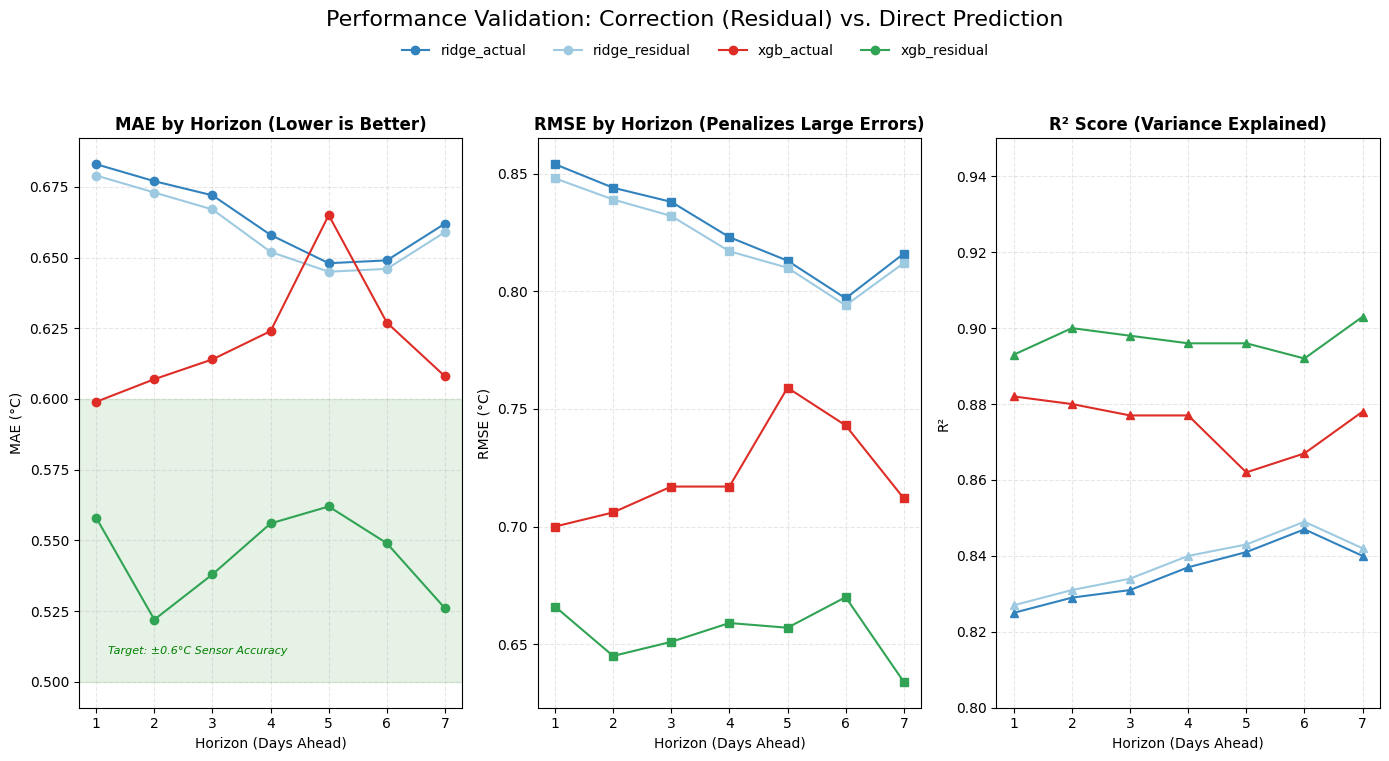

In [ ]:
# Configuration
horizons = list(range(1, 8))
fig, axes = plt.subplots(1, 3, figsize=(14, 7))
model_colors = {'pred_ridge_actual': '#3182bd', 'pred_ridge_residual': '#9ecae1',
                'pred_xgb_actual': '#de2d26', 'pred_xgb_residual': '#31a354'}

lines = []
labels = []

# Plot 1: MAE
ax1 = axes[0]
for model_name, metrics in results.items():
    mae_values = [metrics['MAE_by_horizon'][h] for h in horizons]
    line, = ax1.plot(horizons, mae_values, marker='o', color=model_colors.get(model_name))
    if len(lines) < 4:
        lines.append(line)
        labels.append(model_name.replace('pred_', ''))
ax1.set_title('MAE by Horizon (Lower is Better)', fontweight='bold')
ax1.set_ylabel('MAE (°C)')
ax1.axhspan(0.5, 0.6, color='green', alpha=0.1)
ax1.text(1.2, 0.51, 'Target: ±0.6°C Sensor Accuracy', fontsize=8, color='green', style='italic')

# Plot 2: RMSE
ax2 = axes[1]
for model_name, metrics in results.items():
    rmse_values = [metrics['RMSE_by_horizon'][h] for h in horizons]
    ax2.plot(horizons, rmse_values, marker='s', color=model_colors.get(model_name))
ax2.set_title('RMSE by Horizon (Penalizes Large Errors)', fontweight='bold')
ax2.set_ylabel('RMSE (°C)')

# Plot 3: R²
ax3 = axes[2]
for model_name, metrics in results.items():
    r2_values = [metrics['R2_by_horizon'][h] for h in horizons]
    ax3.plot(horizons, r2_values, marker='^', color=model_colors.get(model_name))
ax3.set_title('R² Score (Variance Explained)', fontweight='bold')
ax3.set_ylabel('R²')
ax3.set_ylim(0.80, 0.95) # Expanded zoom to show 83% vs 90% gap

# Global styling
for ax in axes:
    ax.set_xlabel('Horizon (Days Ahead)')
    ax.set_xticks(horizons)
    ax.grid(True, alpha=0.3, linestyle='--')

fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=False, fontsize=10)
plt.suptitle('Performance Validation: Correction (Residual) vs. Direct Prediction', fontsize=16, y=1.08)
plt.tight_layout()
plt.show()

## Model evaluation result

> XGBoost-residual achieves 0.544°C hourly MAE with R² = 0.897 and balanced peak/trough performance. Forecast accuracy holds across all 7 horizons (0.52–0.56 MAE), reflecting the stability of tropical climate forecasts.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 110)
print("OVERFITTING CHECK — Train vs Test across MAE, RMSE, R²")
print("=" * 110)
print(f"{'Model':<25s} {'Metric':<6s} {'Train':>8s} {'Test':>8s} {'Ratio':>8s}  Flag")
print("-" * 110)

for col, y_col in [
    ('pred_ridge_actual',   'sensor_temp'),
    ('pred_ridge_residual', 'sensor_temp'),
    ('pred_xgb_actual',     'sensor_temp'),
    ('pred_xgb_residual',   'sensor_temp'),
]:
    # ── Generate train predictions ──
    if 'ridge' in col:
        models = ridge_actual_models if 'actual' in col else ridge_residual_models
        train_preds = np.full(len(df_train_scaled), np.nan)
        for h in range(1, 8):
            mask = df_train_scaled['horizon'] == h
            preds = models[h].predict(df_train_scaled.loc[mask, ridge_features])
            if 'residual' in col:
                preds = preds + df_train.loc[df_train['horizon'] == h, 'om_temp'].values
            train_preds[mask.values] = preds
    else:
        model = xgb_actual if 'actual' in col else xgb_residual
        train_preds = model.predict(df_train[xgb_features])
        if 'residual' in col:
            train_preds = train_preds + df_train['om_temp'].values

    y_train_true = df_train['sensor_temp'].values
    y_test_true  = df_test['sensor_temp'].values
    y_test_pred  = df_test_scaled[col].values

    # ── Compute all three metrics on train and test ──
    train_mae  = mean_absolute_error(y_train_true, train_preds)
    test_mae   = mean_absolute_error(y_test_true, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train_true, train_preds))
    test_rmse  = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

    train_r2   = r2_score(y_train_true, train_preds)
    test_r2    = r2_score(y_test_true, y_test_pred)

    # ── Ratios + flags ──
    # For MAE/RMSE: ratio > 1.5 = overfit (test/train, higher = worse)
    # For R²: gap_r2 > 0.10 = overfit (train_r2 - test_r2, higher = worse)
    mae_ratio  = test_mae / train_mae
    rmse_ratio = test_rmse / train_rmse
    r2_gap     = train_r2 - test_r2

    def flag_ratio(r):
        if r > 1.5:  return '⚠️  OVERFIT'
        if r > 1.2:  return '⚡ MILD'
        return '✅ OK'

    def flag_r2(gap):
        if gap > 0.15: return '⚠️  OVERFIT'
        if gap > 0.08: return '⚡ MILD'
        return '✅ OK'

    print(f"{col:<25s} {'MAE':<6s} {train_mae:>8.3f} {test_mae:>8.3f} {mae_ratio:>8.2f}  {flag_ratio(mae_ratio)}")
    print(f"{'':<25s} {'RMSE':<6s} {train_rmse:>8.3f} {test_rmse:>8.3f} {rmse_ratio:>8.2f}  {flag_ratio(rmse_ratio)}")
    print(f"{'':<25s} {'R²':<6s} {train_r2:>8.3f} {test_r2:>8.3f} {r2_gap:>+8.3f}  {flag_r2(r2_gap)}")
    print("-" * 110)

OVERFITTING CHECK — Train vs Test across MAE, RMSE, R²
Model                     Metric    Train     Test    Ratio  Flag
--------------------------------------------------------------------------------------------------------------
pred_ridge_actual         MAE       0.644    0.664     1.03  ✅ OK
                          RMSE      0.811    0.827     1.02  ✅ OK
                          R²        0.840    0.836   +0.004  ✅ OK
--------------------------------------------------------------------------------------------------------------
pred_ridge_residual       MAE       0.645    0.660     1.02  ✅ OK
                          RMSE      0.811    0.822     1.01  ✅ OK
                          R²        0.840    0.838   +0.002  ✅ OK
--------------------------------------------------------------------------------------------------------------
pred_xgb_actual           MAE       0.452    0.621     1.37  ⚡ MILD
                          RMSE      0.564    0.722     1.28  ⚡ MILD
              

## Enforce best model

In [ ]:
# Explicitly update BEST_MODEL to use this fitted instance
BEST_MODEL = xgb_residual

In [ ]:
# Use sensor data directly for historical period
df_gdd_sensor = hourly_df.copy()
df_gdd_sensor['temp_capped'] = df_gdd_sensor['sensor_temp'].clip(lower=10, upper=30)
df_gdd_sensor['date'] = df_gdd_sensor['timestamp'].dt.date

daily_sensor = df_gdd_sensor.groupby('date').agg(
    daily_mean_capped=('temp_capped', 'mean'),
    n_hours=('temp_capped', 'count')
).reset_index()

# Require at least 20 hours for a complete day (filter partial days)
daily_sensor = daily_sensor[daily_sensor['n_hours'] >= 20].copy()
daily_sensor['daily_gdd'] = (daily_sensor['daily_mean_capped'] - 10).clip(lower=0)
daily_sensor['cumulative_gdd'] = daily_sensor['daily_gdd'].cumsum()

print(f"Historical GDD: {daily_sensor['date'].min()} → {daily_sensor['date'].max()}")
print(f"Final cumulative GDD: {daily_sensor['cumulative_gdd'].iloc[-1]:.1f}")
daily_sensor.tail()

Historical GDD: 2026-03-17 → 2026-04-21
Final cumulative GDD: 623.7


,date,daily_mean_capped,n_hours,daily_gdd,cumulative_gdd
32,2026-04-17,27.871959,24,17.871959,553.816973
33,2026-04-18,27.901689,24,17.901689,571.718662
34,2026-04-19,27.531251,24,17.531251,589.249913
35,2026-04-20,27.506749,22,17.506749,606.756662
36,2026-04-21,26.991713,22,16.991713,623.748375


In [ ]:
# For projection period (test set), take diagonal slice:
# day 1 after test starts → horizon 1
# day 2 after test starts → horizon 2
# ...
test_start = df_test_scaled['timestamp'].min().normalize()
df_test_scaled['days_ahead'] = (df_test_scaled['timestamp'].dt.normalize() - test_start).dt.days + 1

# Keep only rows where horizon matches days_ahead (the diagonal)
df_projection = df_test_scaled[df_test_scaled['horizon'] == df_test_scaled['days_ahead']].copy()

print(f"Projection rows: {len(df_projection)}")
print(f"Days covered: {df_projection['days_ahead'].unique()}")
df_projection[['timestamp', 'days_ahead', 'horizon', 'sensor_temp', 'pred_xgb_residual']].head()

Projection rows: 159
Days covered: [1 2 3 4 5 6 7]


,timestamp,days_ahead,horizon,sensor_temp,pred_xgb_residual
0,2026-04-15 05:00:00,1,1,25.289058,25.904897
7,2026-04-15 06:00:00,1,1,24.890617,25.980463
14,2026-04-15 07:00:00,1,1,26.135417,25.749610
21,2026-04-15 08:00:00,1,1,25.953117,26.085464
28,2026-04-15 09:00:00,1,1,26.515633,26.939344


In [ ]:
df_projection['temp_capped_pred'] = df_projection['pred_xgb_residual'].clip(lower=10, upper=30)
df_projection['temp_capped_true'] = df_projection['sensor_temp'].clip(lower=10, upper=30)
df_projection['date'] = df_projection['timestamp'].dt.date

daily_proj = df_projection.groupby('date').agg(
    pred_mean=('temp_capped_pred', 'mean'),
    true_mean=('temp_capped_true', 'mean'),
    n_hours=('temp_capped_pred', 'count')
).reset_index()

daily_proj = daily_proj[daily_proj['n_hours'] >= 20].copy()
daily_proj['pred_gdd'] = (daily_proj['pred_mean'] - 10).clip(lower=0)
daily_proj['true_gdd'] = (daily_proj['true_mean'] - 10).clip(lower=0)

# Continue cumulative GDD from the last historical value
last_hist_gdd = daily_sensor['cumulative_gdd'].iloc[-1]
daily_proj['pred_cumulative'] = last_hist_gdd + daily_proj['pred_gdd'].cumsum()
daily_proj['true_cumulative'] = last_hist_gdd + daily_proj['true_gdd'].cumsum()

print(f"Projection period: {daily_proj['date'].min()} → {daily_proj['date'].max()}")
print()
print(daily_proj[['date', 'true_gdd', 'pred_gdd', 'true_cumulative', 'pred_cumulative']])

Projection period: 2026-04-16 → 2026-04-21

         date   true_gdd   pred_gdd  true_cumulative  pred_cumulative
1  2026-04-16  17.638349  17.363805       641.386724       641.112180
2  2026-04-17  17.871959  17.376081       659.258683       658.488261
3  2026-04-18  17.901689  17.421345       677.160372       675.909606
4  2026-04-19  17.531251  17.331337       694.691624       693.240943
5  2026-04-20  17.506749  17.255176       712.198373       710.496119
6  2026-04-21  16.991713  17.422935       729.190086       727.919054


In [ ]:
gdd_daily_mae = (daily_proj['pred_gdd'] - daily_proj['true_gdd']).abs().mean()
gdd_cum_error_final = abs(daily_proj['pred_cumulative'].iloc[-1] - daily_proj['true_cumulative'].iloc[-1])

print(f"Daily GDD MAE:             {gdd_daily_mae:.3f}")
print(f"Final cumulative GDD error: {gdd_cum_error_final:.3f}")
print(f"Projection total true GDD:   {daily_proj['true_gdd'].sum():.1f}")
print(f"Projection total pred GDD:   {daily_proj['pred_gdd'].sum():.1f}")

Daily GDD MAE:             0.356
Final cumulative GDD error: 1.271
Projection total true GDD:   105.4
Projection total pred GDD:   104.2


In [ ]:
sensor_end_date = daily_sensor['date'].max()
forward_start_ts = pd.Timestamp(sensor_end_date) + pd.Timedelta(days=1)

# Filter OM data to truly future dates
df_forecast = df_om_long[df_om_long['timestamp'] >= forward_start_ts].copy()

# Diagonal slice: each day uses matching horizon
df_forecast['days_ahead'] = (df_forecast['timestamp'].dt.normalize() - forward_start_ts).dt.days + 1
df_forecast = df_forecast[
    (df_forecast['horizon'] == df_forecast['days_ahead']) &
    (df_forecast['days_ahead'].between(1, 7))
].copy()

# Feature engineer (matching the training set features)
df_forecast['hour_of_day'] = df_forecast['timestamp'].dt.hour
df_forecast['hour_sin'] = np.sin(2 * np.pi * df_forecast['hour_of_day'] / 24)
df_forecast['hour_cos'] = np.cos(2 * np.pi * df_forecast['hour_of_day'] / 24)

# Predict with BEST_MODEL (XGBoost Residual)
pred_resid = BEST_MODEL.predict(df_forecast[xgb_features])
df_forecast['pred_field_temp'] = pred_resid + df_forecast['om_temp'].values

# Daily GDD Calculation
df_forecast['temp_capped'] = df_forecast['pred_field_temp'].clip(10, 30)
df_forecast['date'] = df_forecast['timestamp'].dt.date

daily_forecast = df_forecast.groupby('date').agg(
    pred_mean=('temp_capped', 'mean'),
    n_hours=('temp_capped', 'count')
).reset_index()

daily_forecast = daily_forecast[daily_forecast['n_hours'] >= 20]
daily_forecast['pred_gdd'] = (daily_forecast['pred_mean'] - 10).clip(lower=0)

# Cumulative GDD starting from the last historical point
cumulative_at_sensor_end = daily_sensor['cumulative_gdd'].iloc[-1]
daily_forecast['cumulative_gdd'] = cumulative_at_sensor_end + daily_forecast['pred_gdd'].cumsum()

print(f"Sensor data ends on {sensor_end_date} with cumulative GDD = {cumulative_at_sensor_end:.1f}")
display(daily_forecast)

Sensor data ends on 2026-04-21 with cumulative GDD = 623.7


,date,pred_mean,n_hours,pred_gdd,cumulative_gdd
0,2026-04-22,27.411019,24,17.411019,641.159394
1,2026-04-23,27.313575,24,17.313575,658.472969
2,2026-04-24,27.316014,24,17.316014,675.788983
3,2026-04-25,27.383417,24,17.383417,693.172400
4,2026-04-26,27.261549,24,17.261549,710.433949
5,2026-04-27,27.272112,24,17.272112,727.706061
6,2026-04-28,27.395686,24,17.395686,745.101747


In [ ]:
# Planting date (from V0 observation)
planting_date = pd.Timestamp('2026-03-16')

# Load growth log
growth_df = pd.read_csv('/content/drive/MyDrive/DA/growth.csv')

stage_map = {'V0': 0, 'VE': 0.5, 'V1': 1, 'V2': 2,
             'V3': 3, 'V4': 4, 'V5': 5, 'V6': 6}

growth_df['stage']     = growth_df['growth_progress_in_gdd']
growth_df['stage_num'] = growth_df['stage'].map(stage_map)
growth_df['date']      = pd.to_datetime(growth_df['created_at']).dt.normalize()

In [ ]:
growth_df

,id,farm_id,growth_progress_in_gdd,height,n_ears,notes,created_at,stage,stage_num,date
0,7,1,V0,0.0,0,0.0,2026-03-16 08:02:00,V0,0.0,2026-03-16
1,8,1,VE,0.3,0,0.0,2026-03-20 08:42:00,VE,0.5,2026-03-20
2,9,1,V1,2.6,0,0.0,2026-03-25 11:36:19,V1,1.0,2026-03-25
3,10,1,V2,5.6,0,NaN,2026-03-31 14:26:31,V2,2.0,2026-03-31
4,11,1,V3,14.2,0,NaN,2026-04-03 20:42:33,V3,3.0,2026-04-03
5,12,1,V4,22.5,0,NaN,2026-04-07 16:30:48,V4,4.0,2026-04-07
6,13,1,V5,29.1,0,NaN,2026-04-12 08:31:40,V5,5.0,2026-04-12
7,14,1,V6,42.3,0,NaN,2026-04-17 11:20:17,V6,6.0,2026-04-17


In [ ]:
growth_df.shape

(8, 10)

In [ ]:
growth_df.describe()

,id,farm_id,height,n_ears,notes,stage_num,date
count,8.00000,8.0,8.000000,8.0,3.0,8.000000,8
mean,10.50000,1.0,14.575000,0.0,0.0,2.687500,2026-03-31 21:00:00
min,7.00000,1.0,0.000000,0.0,0.0,0.000000,2026-03-16 00:00:00
25%,8.75000,1.0,2.025000,0.0,0.0,0.875000,2026-03-23 18:00:00
50%,10.50000,1.0,9.900000,0.0,0.0,2.500000,2026-04-01 12:00:00
75%,12.25000,1.0,24.150000,0.0,0.0,4.250000,2026-04-08 06:00:00
max,14.00000,1.0,42.300000,0.0,0.0,6.000000,2026-04-17 00:00:00
std,2.44949,0.0,15.504631,0.0,0.0,2.186607,NaN


In [ ]:
from sklearn.linear_model import LinearRegression

stage_gdd_df = growth_df[['date', 'stage', 'stage_num']].merge(
    daily_sensor[['date', 'cumulative_gdd']].assign(
        date=lambda x: pd.to_datetime(x['date'])
    ),
    on='date',
    how='left'
).fillna({'cumulative_gdd': 0})

print(stage_gdd_df[['date', 'stage', 'stage_num', 'cumulative_gdd']])

# days_since_planting must be in the same block as stage_gdd_df creation
stage_gdd_df['days_since_planting'] = (stage_gdd_df['date'] - planting_date).dt.days

baseline_model = LinearRegression().fit(
    stage_gdd_df[['days_since_planting']].values,
    stage_gdd_df['stage_num'].values
)

print(f"Baseline: stage = {baseline_model.coef_[0]:.4f} × days + {baseline_model.intercept_:.4f}")

# Fit stage → GDD regression
X_stage = stage_gdd_df[['stage_num']].values
y_stage = stage_gdd_df['cumulative_gdd'].values
stage_gdd_model = LinearRegression().fit(X_stage, y_stage)

print(f"Stage regression: GDD = {stage_gdd_model.coef_[0]:.1f} × stage + {stage_gdd_model.intercept_:.1f}")
print(f"Avg GDD per stage on your farm: {stage_gdd_model.coef_[0]:.1f}")

# Combined curve for crossing check
combined = pd.concat([
    daily_sensor[['date', 'cumulative_gdd']].assign(source='historical'),
    daily_forecast[['date', 'cumulative_gdd']].assign(source='forecast'),
], ignore_index=True).sort_values('date').reset_index(drop=True)

# Predict V7, V8
for stage_target in [7, 8]:
    threshold = stage_gdd_model.predict([[stage_target]])[0]
    crossing = combined[combined['cumulative_gdd'] >= threshold]

    if len(crossing) > 0:
        pred_date = crossing.iloc[0]['date']
        pred_source = crossing.iloc[0]['source']
        print(f"V{stage_target}: threshold = {threshold:.0f} GDD → predicted {pred_date} (from {pred_source})")
    else:
        shortfall = threshold - combined['cumulative_gdd'].iloc[-1]
        days_needed = shortfall / 17
        last_date = pd.Timestamp(combined['date'].iloc[-1])
        extrapolated = (last_date + pd.Timedelta(days=days_needed)).date()
        print(f"V{stage_target}: threshold = {threshold:.0f} GDD → not reached in window, est {extrapolated} (~{days_needed:.1f} days past forecast)")

# Baseline predictions
for stage_target in [7, 8]:
    days_baseline = (stage_target - baseline_model.intercept_) / baseline_model.coef_[0]
    date_baseline = (planting_date + pd.Timedelta(days=days_baseline)).date()
    print(f"V{stage_target} (baseline linear time): {date_baseline}")

        date stage  stage_num  cumulative_gdd
0 2026-03-16    V0        0.0        0.000000
1 2026-03-20    VE        0.5       70.220378
2 2026-03-25    V1        1.0      155.648848
3 2026-03-31    V2        2.0      260.280098
4 2026-04-03    V3        3.0      311.962281
5 2026-04-07    V4        4.0      382.063934
6 2026-04-12    V5        5.0      468.308940
7 2026-04-17    V6        6.0      553.816973
Baseline: stage = 0.1946 × days + -0.4017
Stage regression: GDD = 87.3 × stage + 40.7
Avg GDD per stage on your farm: 87.3
V7: threshold = 652 GDD → predicted 2026-04-23 (from forecast)
V8: threshold = 739 GDD → predicted 2026-04-28 (from forecast)
V7 (baseline linear time): 2026-04-23
V8 (baseline linear time): 2026-04-28


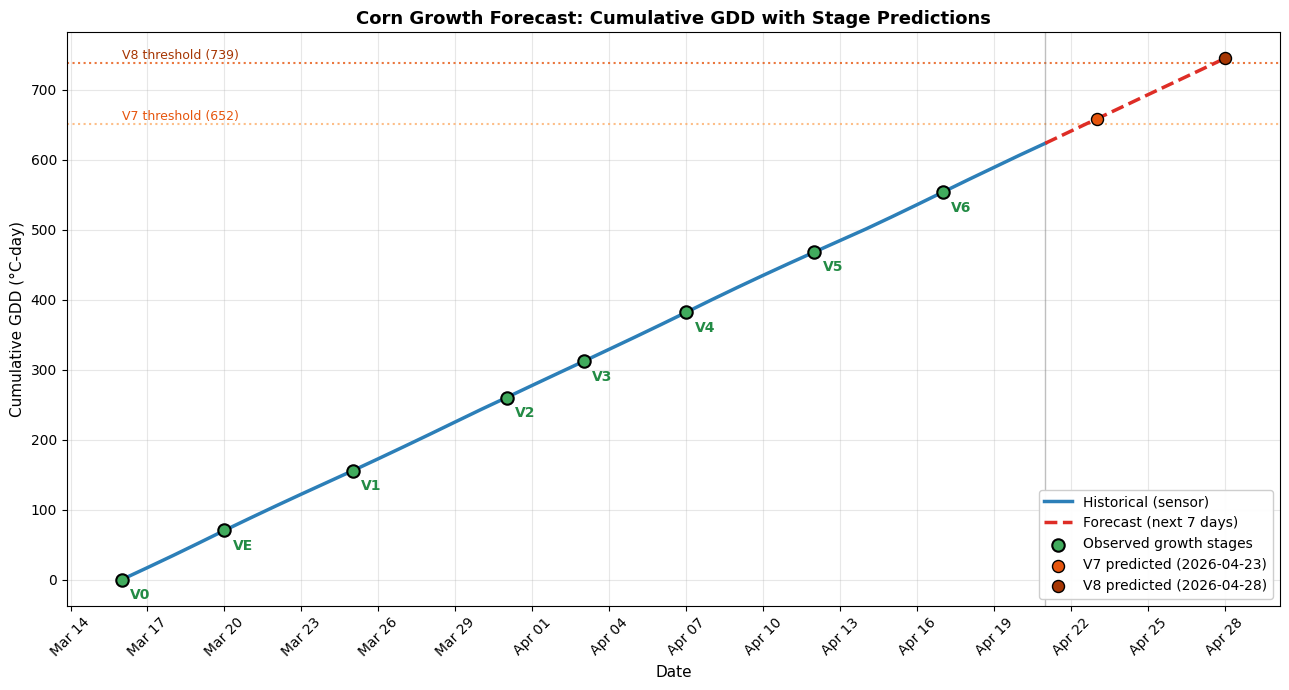

In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))


# Combine historical + forecast into one curve
combined = pd.concat([
    pd.DataFrame([{'date': pd.to_datetime(planting_date), 'cumulative_gdd': 0, 'source': 'historical'}]),
    daily_sensor[['date', 'cumulative_gdd']].assign(
        date=lambda x: pd.to_datetime(x['date']), source='historical'),
    daily_forecast[['date', 'cumulative_gdd']].assign(
        date=lambda x: pd.to_datetime(x['date']), source='forecast'),
], ignore_index=True).sort_values('date').reset_index(drop=True)

# Historical (solid)
hist = combined[combined['source'] == 'historical']
ax.plot(hist['date'], hist['cumulative_gdd'],
        color='#2c7fb8', linewidth=2.5, label='Historical (sensor)', zorder=3)

# Forecast (dashed) - connect last historical point to first forecast point
fcst = combined[combined['source'] == 'forecast']
connector = pd.concat([hist.tail(1), fcst])
ax.plot(connector['date'], connector['cumulative_gdd'],
        color='#de2d26', linewidth=2.5, linestyle='--',
        label='Forecast (next 7 days)', zorder=3)

# Growth log observations as dots
stage_gdd_df_plot = stage_gdd_df.copy()
stage_gdd_df_plot['date'] = pd.to_datetime(stage_gdd_df_plot['date'])

# Ensure V0 is included (planting day, 0 GDD)
if 'V0' not in stage_gdd_df_plot['stage'].values:
    v0_row = pd.DataFrame([{
        'stage': 'V0',
        'stage_num': 0,
        'date': pd.to_datetime(planting_date),
        'cumulative_gdd': 0,
    }])
    stage_gdd_df_plot = pd.concat([v0_row, stage_gdd_df_plot], ignore_index=True)

# Plot all stages including V0
ax.scatter(stage_gdd_df_plot['date'], stage_gdd_df_plot['cumulative_gdd'],
           color='#41ab5d', s=80, zorder=5, edgecolors='black', linewidths=1.5,
           label='Observed growth stages')

# Label each stage dot
for _, row in stage_gdd_df_plot.iterrows():
    ax.annotate(row['stage'],
                (row['date'], row['cumulative_gdd']),
                textcoords="offset points", xytext=(6, -14),
                fontsize=10, fontweight='bold', color='#238b45')

# V7, V8 thresholds as horizontal lines
v7_thresh = stage_gdd_model.predict([[7]])[0]
v8_thresh = stage_gdd_model.predict([[8]])[0]

ax.axhline(y=v7_thresh, color='#fdae6b', linestyle=':', linewidth=1.5, alpha=0.8)
ax.axhline(y=v8_thresh, color='#e6550d', linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(combined['date'].min(), v7_thresh + 5, f'V7 threshold ({v7_thresh:.0f})',
        fontsize=9, color='#e6550d')
ax.text(combined['date'].min(), v8_thresh + 5, f'V8 threshold ({v8_thresh:.0f})',
        fontsize=9, color='#a63603')

# Vertical line at sensor/forecast seam
seam_date = pd.to_datetime(daily_sensor['date'].max())
ax.axvline(x=seam_date, color='gray', linestyle='-', linewidth=1, alpha=0.5)

# Calculate V7 and V8 prediction dates AND their actual GDD on the curve
v7_pred_date = None
v7_pred_gdd = None
v8_pred_date = None
v8_pred_gdd = None

for stage_target in [7, 8]:
    threshold = stage_gdd_model.predict([[stage_target]])[0]
    crossing = combined[combined['cumulative_gdd'] >= threshold]

    if len(crossing) > 0:
        pred_date = pd.Timestamp(crossing.iloc[0]['date'])
        pred_gdd = crossing.iloc[0]['cumulative_gdd']
        if stage_target == 7:
            v7_pred_date = pred_date
            v7_pred_gdd = pred_gdd
        if stage_target == 8:
            v8_pred_date = pred_date
            v8_pred_gdd = pred_gdd

# Mark V7 prediction (on the curve, not on the threshold line)
if v7_pred_date is not None:
    ax.scatter([v7_pred_date], [v7_pred_gdd], color='#e6550d',
               s=75, zorder=6, edgecolors='black', linewidths=1,
               label=f'V7 predicted ({v7_pred_date.date()})')

# Mark V8 prediction (on the curve, not on the threshold line)
if v8_pred_date is not None:
    ax.scatter([v8_pred_date], [v8_pred_gdd], color='#a63603',
               s=75, zorder=6, edgecolors='black', linewidths=1,
               label=f'V8 predicted ({v8_pred_date.date()})')

# Styling
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Cumulative GDD (°C-day)', fontsize=11)
ax.set_title('Corn Growth Forecast: Cumulative GDD with Stage Predictions',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)
ax.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def run_ablation_full(features, label, target_col='residual'):
    """Train XGBoost-residual with given feature set, return MAE, RMSE, R²."""
    xgb_model = XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1
    )
    xgb_model.fit(df_train[features], df_train[target_col])
    pred_resid = xgb_model.predict(df_test[features])
    pred_temp  = pred_resid + df_test['om_temp'].values
    y_true = df_test['sensor_temp'].values

    mae  = mean_absolute_error(y_true, pred_temp)
    rmse = np.sqrt(mean_squared_error(y_true, pred_temp))
    r2   = r2_score(y_true, pred_temp)

    return {'label': label, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Setup raw hour for comparison
df_train['hour_raw'] = df_train['timestamp'].dt.hour
df_test['hour_raw']  = df_test['timestamp'].dt.hour

# Run ablations on valid features only
ablations = []
ablations.append(run_ablation_full(
    xgb_features,
    'Best Model'
))
ablations.append(run_ablation_full(
    ['om_temp', 'hour_raw', 'horizon'],
    'no cyclic encoding'
))
ablations.append(run_ablation_full(
    ['om_temp', 'hour_sin', 'hour_cos'],
    'no horizon feature'
))
ablations.append(run_ablation_full(
    ['om_temp'],
    'only om_temp'
))

# Build comparison table
ablation_df = pd.DataFrame(ablations)
base = ablation_df.iloc[0]

ablation_df['MAE_Δ%']  = ((ablation_df['MAE']  - base['MAE'])  / base['MAE']  * 100).round(1)
ablation_df['RMSE_Δ%'] = ((ablation_df['RMSE'] - base['RMSE']) / base['RMSE'] * 100).round(1)
ablation_df['R2_Δ']    = (ablation_df['R2']    - base['R2']).round(3)

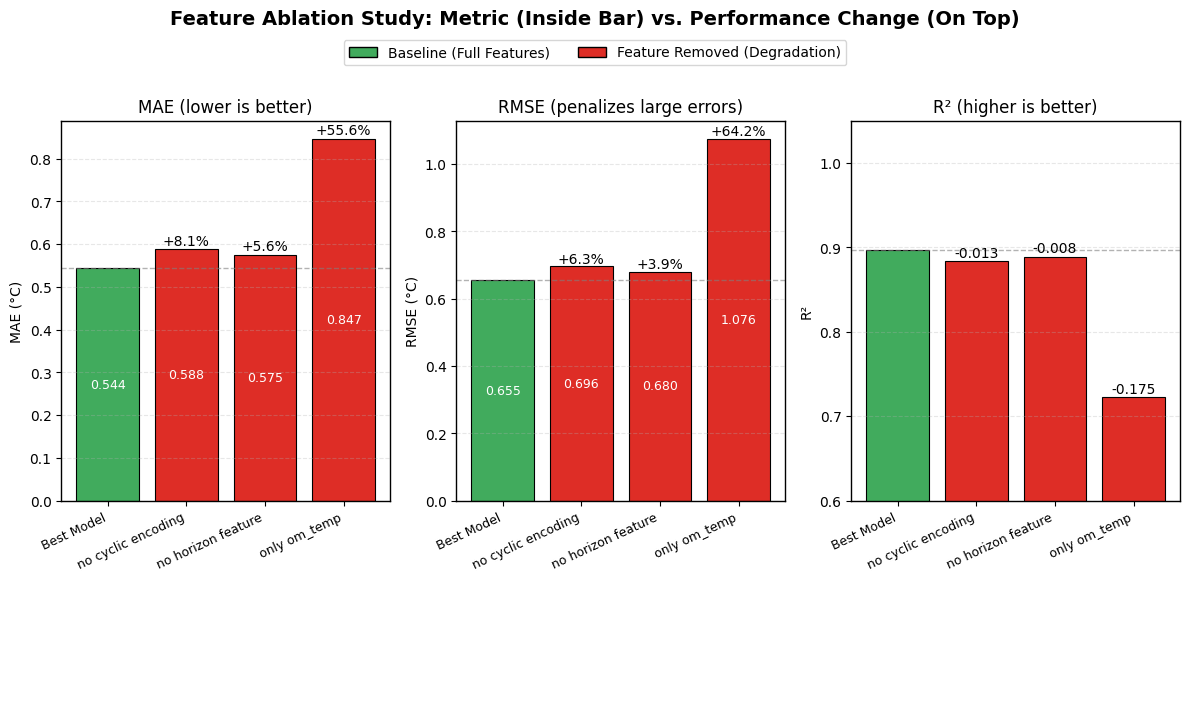

In [ ]:
from matplotlib.patches import Patch

# ─── Build the comparison chart ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 8))

labels = ablation_df['label'].tolist()
x = np.arange(len(labels))

# Color: baseline green, others red-orange (degraded)
colors = ['#41ab5d'] + ['#de2d26'] * (len(labels) - 1)

# ─── Panel 1: MAE ────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(x, ablation_df['MAE'], color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(y=ablation_df['MAE'].iloc[0], color='gray', linestyle='--', linewidth=1, alpha=0.6)

for bar, val, delta in zip(bars, ablation_df['MAE'], ablation_df['MAE_Δ%']):
    # Absolute value inside the bar
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, f'{val:.3f}',
            ha='center', va='center', fontsize=9, color='white')
    # Delta % on top
    if delta != 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{delta:+.1f}%',
                ha='center', fontsize=10, color='black')

ax.set_title('MAE (lower is better)', fontweight='medium')
ax.set_ylabel('MAE (°C)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# ─── Panel 2: RMSE ───────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(x, ablation_df['RMSE'], color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(y=ablation_df['RMSE'].iloc[0], color='gray', linestyle='--', linewidth=1, alpha=0.6)

for bar, val, delta in zip(bars, ablation_df['RMSE'], ablation_df['RMSE_Δ%']):
    # Absolute value inside
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, f'{val:.3f}',
            ha='center', va='center', fontsize=9, color='white')
    # Delta % on top
    if delta != 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{delta:+.1f}%',
                ha='center', fontsize=10, color='black')

ax.set_title('RMSE (penalizes large errors)', fontweight='medium')
ax.set_ylabel('RMSE (°C)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# ─── Panel 3: R² ─────────────────────────────────────────────────
ax = axes[2]
bars = ax.bar(x, ablation_df['R2'], color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(y=ablation_df['R2'].iloc[0], color='gray', linestyle='--', linewidth=1, alpha=0.6)

for bar, val, delta in zip(bars, ablation_df['R2'], ablation_df['R2_Δ']):
    # Absolute value inside
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, f'{val:.3f}',
            ha='center', va='center', fontsize=9, color='white')
    # Delta on top
    if delta != 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{delta:+.3f}',
                ha='center', fontsize=10, color='black')

ax.set_title('R² (higher is better)', fontweight='medium')
ax.set_ylabel('R²')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
ax.set_ylim(0.6, 1.05)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# ─── Styling and Borders ─────────────────────────────────────────
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_edgecolor('black')

fig.suptitle('Feature Ablation Study: Metric (Inside Bar) vs. Performance Change (On Top)',
             fontsize=14, fontweight='bold', y=1.05)

legend_elements = [
    Patch(facecolor='#41ab5d', edgecolor='black', label='Baseline (Full Features)'),
    Patch(facecolor='#de2d26', edgecolor='black', label='Feature Removed (Degradation)'),
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)

plt.tight_layout()
plt.show()

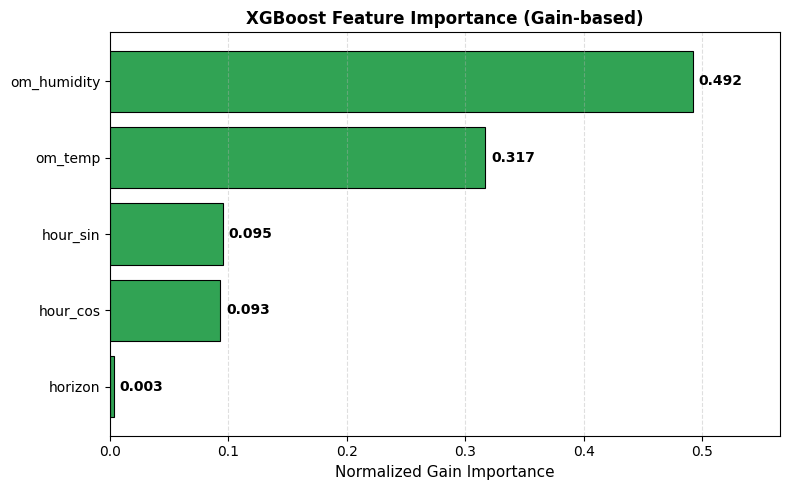

In [ ]:
# Use gain explicitly, get from booster directly
importance_dict = xgb_residual.get_booster().get_score(importance_type='gain')

# Convert to DataFrame and normalize to sum to 1.0 (so "0.49" reads as 49%)
feat_imp_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Importance': list(importance_dict.values())
})
feat_imp_df['Importance'] = feat_imp_df['Importance'] / feat_imp_df['Importance'].sum()
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True).reset_index(drop=True)

# Plot
plt.figure(figsize=(8, 5))
ax = plt.gca()
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
               color='#31a354', edgecolor='black', linewidth=0.8)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
            f'{width:.3f}', va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_xlabel('Normalized Gain Importance', fontsize=11)
ax.set_title('XGBoost Feature Importance (Gain-based)', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(feat_imp_df['Importance']) * 1.15)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Feature Importance

- **Humidity (0.49)** — dominant; drives the OM→field deviation via evapotranspiration
- **OM temperature (0.32)** — baseline anchor for residual correction
- **Cyclic hour (0.19 combined)** — captures diurnal canopy effects
- **Horizon (0.003)** — negligible; tropical forecasts stable across 7 days

Same ranking as ablation study — two methods agree.

## GDD Difference: Observed vs. Model Predicted for Stages

This chart compares the actual cumulative Growing Degree Days (GDD) recorded at each observed growth stage with the GDD that our `stage_gdd_model` predicts for that particular stage. A difference close to zero indicates that the model accurately estimates the GDD for that stage based on the historical trend.

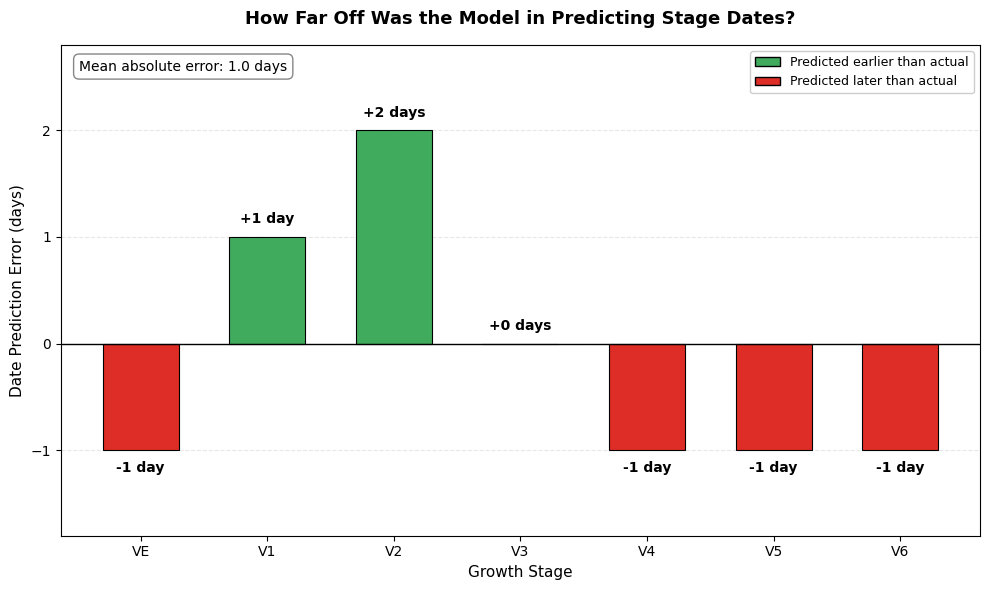

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# For each observed stage, compute the date prediction error
stage_residuals = stage_gdd_df.copy()
stage_residuals = stage_residuals[stage_residuals['stage'] != 'V0'].copy()
stage_residuals['predicted_gdd_threshold'] = stage_gdd_model.predict(
    stage_residuals[['stage_num']].values
)

predicted_dates = []
for _, row in stage_residuals.iterrows():
    threshold = row['predicted_gdd_threshold']
    crossing = daily_sensor[daily_sensor['cumulative_gdd'] >= threshold]
    if len(crossing) > 0:
        predicted_dates.append(pd.Timestamp(crossing.iloc[0]['date']))
    else:
        predicted_dates.append(None)

stage_residuals['predicted_date'] = predicted_dates
stage_residuals['actual_date'] = pd.to_datetime(stage_residuals['date'])
stage_residuals['day_diff'] = (
    stage_residuals['actual_date'] - stage_residuals['predicted_date']
).dt.days

# ── Plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#41ab5d' if x >= 0 else '#de2d26' for x in stage_residuals['day_diff']]

bars = ax.bar(stage_residuals['stage'], stage_residuals['day_diff'],
              color=colors, edgecolor='black', linewidth=0.8, width=0.6)

ax.axhline(y=0, color='black', linewidth=1)

# Place value labels OUTSIDE the bar (above for positive, below for negative)
for bar, val in zip(bars, stage_residuals['day_diff']):
    height = bar.get_height()
    if height >= 0:
        label_y = height + 0.1
        va = 'bottom'
    else:
        label_y = height - 0.1
        va = 'top'
    ax.text(bar.get_x() + bar.get_width()/2, label_y,
            f'{int(val):+d} day{"s" if abs(val) != 1 else ""}',
            ha='center', va=va, fontsize=10, fontweight='bold')

# ── Styling ──────────────────────────────────────────
ax.set_xlabel('Growth Stage', fontsize=11)
ax.set_ylabel('Date Prediction Error (days)', fontsize=11)
ax.set_title('How Far Off Was the Model in Predicting Stage Dates?',
             fontsize=13, fontweight='bold', pad=15)

# Expand y-axis to give label space
y_max = stage_residuals['day_diff'].max() + 0.8
y_min = stage_residuals['day_diff'].min() - 0.8
ax.set_ylim(y_min, y_max)

# Force integer ticks on y-axis (days are whole numbers)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#41ab5d', edgecolor='black', label='Predicted earlier than actual'),
    Patch(facecolor='#de2d26', edgecolor='black', label='Predicted later than actual'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.95)

# Mean annotation
mae_days = stage_residuals['day_diff'].abs().mean()
ax.text(0.02, 0.97, f'Mean absolute error: {mae_days:.1f} days',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='gray', alpha=0.95))

# Grid only on horizontal lines
ax.grid(alpha=0.3, axis='y', linestyle='--')
ax.set_axisbelow(True)

# Remove duplicate x-axis labels (matplotlib doesn't add these by default,
# the issue in your screenshot was Canva or rendering artifact — this code is clean)

plt.tight_layout()
plt.show()

In [ ]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas

In [ ]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://previous-runs-api.open-meteo.com/v1/forecast"
params = {
	"latitude": 13.845167,
	"longitude": 100.570103,
	"hourly": ["temperature_2m_previous_day1", "temperature_2m_previous_day2", "temperature_2m_previous_day3", "temperature_2m_previous_day4", "temperature_2m_previous_day5", "temperature_2m_previous_day6", "temperature_2m_previous_day7", "relative_humidity_2m_previous_day1", "relative_humidity_2m_previous_day2", "relative_humidity_2m_previous_day3", "relative_humidity_2m_previous_day4", "relative_humidity_2m_previous_day5", "relative_humidity_2m_previous_day6", "relative_humidity_2m_previous_day7", "shortwave_radiation_previous_day1", "shortwave_radiation_previous_day2", "shortwave_radiation_previous_day3", "shortwave_radiation_previous_day4", "shortwave_radiation_previous_day5", "shortwave_radiation_previous_day6", "shortwave_radiation_previous_day7"],
	"models": "best_match",
	"timezone": "Asia/Bangkok",
	"start_date": "2026-03-08",
	"end_date": "2026-04-29",
	"temporal_resolution": "native",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m_previous_day1 = hourly.Variables(0).ValuesAsNumpy()
hourly_temperature_2m_previous_day2 = hourly.Variables(1).ValuesAsNumpy()
hourly_temperature_2m_previous_day3 = hourly.Variables(2).ValuesAsNumpy()
hourly_temperature_2m_previous_day4 = hourly.Variables(3).ValuesAsNumpy()
hourly_temperature_2m_previous_day5 = hourly.Variables(4).ValuesAsNumpy()
hourly_temperature_2m_previous_day6 = hourly.Variables(5).ValuesAsNumpy()
hourly_temperature_2m_previous_day7 = hourly.Variables(6).ValuesAsNumpy()
hourly_relative_humidity_2m_previous_day1 = hourly.Variables(7).ValuesAsNumpy()
hourly_relative_humidity_2m_previous_day2 = hourly.Variables(8).ValuesAsNumpy()
hourly_relative_humidity_2m_previous_day3 = hourly.Variables(9).ValuesAsNumpy()
hourly_relative_humidity_2m_previous_day4 = hourly.Variables(10).ValuesAsNumpy()
hourly_relative_humidity_2m_previous_day5 = hourly.Variables(11).ValuesAsNumpy()
hourly_relative_humidity_2m_previous_day6 = hourly.Variables(12).ValuesAsNumpy()
hourly_relative_humidity_2m_previous_day7 = hourly.Variables(13).ValuesAsNumpy()
# hourly_shortwave_radiation_previous_day1 = hourly.Variables(14).ValuesAsNumpy()
# hourly_shortwave_radiation_previous_day2 = hourly.Variables(15).ValuesAsNumpy()
# hourly_shortwave_radiation_previous_day3 = hourly.Variables(16).ValuesAsNumpy()
# hourly_shortwave_radiation_previous_day4 = hourly.Variables(17).ValuesAsNumpy()
# hourly_shortwave_radiation_previous_day5 = hourly.Variables(18).ValuesAsNumpy()
# hourly_shortwave_radiation_previous_day6 = hourly.Variables(19).ValuesAsNumpy()
# hourly_shortwave_radiation_previous_day7 = hourly.Variables(20).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m_previous_day1"] = hourly_temperature_2m_previous_day1
hourly_data["temperature_2m_previous_day2"] = hourly_temperature_2m_previous_day2
hourly_data["temperature_2m_previous_day3"] = hourly_temperature_2m_previous_day3
hourly_data["temperature_2m_previous_day4"] = hourly_temperature_2m_previous_day4
hourly_data["temperature_2m_previous_day5"] = hourly_temperature_2m_previous_day5
hourly_data["temperature_2m_previous_day6"] = hourly_temperature_2m_previous_day6
hourly_data["temperature_2m_previous_day7"] = hourly_temperature_2m_previous_day7
hourly_data["relative_humidity_2m_previous_day1"] = hourly_relative_humidity_2m_previous_day1
hourly_data["relative_humidity_2m_previous_day2"] = hourly_relative_humidity_2m_previous_day2
hourly_data["relative_humidity_2m_previous_day3"] = hourly_relative_humidity_2m_previous_day3
hourly_data["relative_humidity_2m_previous_day4"] = hourly_relative_humidity_2m_previous_day4
hourly_data["relative_humidity_2m_previous_day5"] = hourly_relative_humidity_2m_previous_day5
hourly_data["relative_humidity_2m_previous_day6"] = hourly_relative_humidity_2m_previous_day6
hourly_data["relative_humidity_2m_previous_day7"] = hourly_relative_humidity_2m_previous_day7
# hourly_data["shortwave_radiation_previous_day1"] = hourly_shortwave_radiation_previous_day1
# hourly_data["shortwave_radiation_previous_day2"] = hourly_shortwave_radiation_previous_day2
# hourly_data["shortwave_radiation_previous_day3"] = hourly_shortwave_radiation_previous_day3
# hourly_data["shortwave_radiation_previous_day4"] = hourly_shortwave_radiation_previous_day4
# hourly_data["shortwave_radiation_previous_day5"] = hourly_shortwave_radiation_previous_day5
# hourly_data["shortwave_radiation_previous_day6"] = hourly_shortwave_radiation_previous_day6
# hourly_data["shortwave_radiation_previous_day7"] = hourly_shortwave_radiation_previous_day7

hourly_weather_df_mod = pd.DataFrame(data = hourly_data)
hourly_weather_df_mod



Coordinates: 13.813708305358887°N 100.5882339477539°E
Elevation: 9.0 m asl
Timezone: b'Asia/Bangkok'b'GMT+7'
Timezone difference to GMT+0: 25200s


,date,temperature_2m_previous_day1,temperature_2m_previous_day2,temperature_2m_previous_day3,temperature_2m_previous_day4,temperature_2m_previous_day5,temperature_2m_previous_day6,temperature_2m_previous_day7,relative_humidity_2m_previous_day1,relative_humidity_2m_previous_day2,relative_humidity_2m_previous_day3,relative_humidity_2m_previous_day4,relative_humidity_2m_previous_day5,relative_humidity_2m_previous_day6,relative_humidity_2m_previous_day7
0,2026-03-08 00:00:00+00:00,30.200001,29.900000,30.100000,29.600000,26.450001,28.549999,28.150000,52.295811,57.309628,60.059532,66.299614,92.860535,77.822716,71.239342
1,2026-03-08 01:00:00+00:00,29.049999,28.950001,29.250000,29.049999,28.200001,28.049999,27.700001,65.785789,74.011604,56.100899,62.836700,82.324234,82.060928,72.470360
2,2026-03-08 02:00:00+00:00,28.549999,28.400000,28.299999,28.600000,27.799999,27.549999,27.150000,72.398643,79.926682,60.766148,64.102562,84.771065,86.018875,74.388283
3,2026-03-08 03:00:00+00:00,28.350000,28.049999,27.799999,28.200001,27.450001,26.900000,26.400000,70.843933,82.306435,64.129417,65.209160,86.266159,90.432274,77.272461
4,2026-03-08 04:00:00+00:00,27.900000,27.549999,27.200001,27.799999,27.100000,26.299999,25.650000,68.215950,82.000572,68.288826,66.339142,87.269714,94.526131,80.287872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,2026-04-29 19:00:00+00:00,31.400000,30.850000,31.250000,31.049999,31.100000,32.400002,31.299999,66.462196,69.404091,68.042160,67.800163,69.658386,52.687660,65.847176
1268,2026-04-29 20:00:00+00:00,30.650000,30.500000,30.500000,30.450001,30.549999,31.750000,30.799999,72.544296,74.487152,71.444595,72.509911,73.396172,57.396790,68.980690
1269,2026-04-29 21:00:00+00:00,30.350000,30.299999,30.400000,30.200001,30.200001,31.150000,30.450001,75.129906,75.794434,74.470970,75.778915,76.457001,62.530270,71.222557
1270,2026-04-29 22:00:00+00:00,30.200001,30.100000,30.299999,29.950001,29.950001,30.650000,30.250000,76.230370,76.897095,74.676582,78.721054,78.488152,67.722198,72.692154


In [ ]:
# Verify Bangkok-trained model and feature set are still available
print("Model type:", type(xgb_residual).__name__)
print("Features model was trained on:", xgb_residual.get_booster().feature_names)
print("xgb_features list:", xgb_features)

# Quick sanity check: predict on Bangkok test set to confirm baseline
pred_check = xgb_residual.predict(df_test[xgb_features])
pred_temp_check = pred_check + df_test['om_temp'].values
mae_check = np.abs(pred_temp_check - df_test['sensor_temp']).mean()
print(f"\nBangkok test MAE (sanity check): {mae_check:.3f}")
print("Expected: ~0.544")

Model type: XGBRegressor
Features model was trained on: ['om_temp', 'om_humidity', 'hour_sin', 'hour_cos', 'horizon']
xgb_features list: ['om_temp', 'om_humidity', 'hour_sin', 'hour_cos', 'horizon']

Bangkok test MAE (sanity check): 0.544
Expected: ~0.544


In [ ]:
# Verify Chiang Mai OM data is loaded
print("Chiang Mai data shape:", hourly_weather_df_mod.shape)
print("\nFirst few rows:")
print(hourly_weather_df_mod.head())
print("\nColumns:")
print(hourly_weather_df_mod.columns.tolist())
print("\nDate range:")
print(f"  Start: {hourly_weather_df_mod['date'].min()}")
print(f"  End:   {hourly_weather_df_mod['date'].max()}")

Chiang Mai data shape: (1272, 15)

First few rows:
                       date  temperature_2m_previous_day1  \
0 2026-03-08 00:00:00+00:00                     30.200001   
1 2026-03-08 01:00:00+00:00                     29.049999   
2 2026-03-08 02:00:00+00:00                     28.549999   
3 2026-03-08 03:00:00+00:00                     28.350000   
4 2026-03-08 04:00:00+00:00                     27.900000   

   temperature_2m_previous_day2  temperature_2m_previous_day3  \
0                     29.900000                     30.100000   
1                     28.950001                     29.250000   
2                     28.400000                     28.299999   
3                     28.049999                     27.799999   
4                     27.549999                     27.200001   

   temperature_2m_previous_day4  temperature_2m_previous_day5  \
0                     29.600000                     26.450001   
1                     29.049999                     28.200001

In [ ]:
# Reshape Chiang Mai wide format → long format
df_om_chiangmai_wide = hourly_weather_df_mod.rename(columns={'date': 'timestamp'})
df_om_chiangmai_wide['timestamp'] = pd.to_datetime(df_om_chiangmai_wide['timestamp'])

# Strip timezone if present (handles both fresh fetch and CSV reload)
if df_om_chiangmai_wide['timestamp'].dt.tz is not None:
    df_om_chiangmai_wide['timestamp'] = df_om_chiangmai_wide['timestamp'].dt.tz_localize(None)

# Reshape wide → long
frames = []
for h in range(1, 8):
    sub = df_om_chiangmai_wide[['timestamp',
        f'temperature_2m_previous_day{h}',
        f'relative_humidity_2m_previous_day{h}',
    ]].copy()
    sub.columns = ['timestamp', 'om_temp', 'om_humidity']
    sub['horizon'] = h
    frames.append(sub)

df_om_chiangmai_long = pd.concat(frames, ignore_index=True)

# Add cyclic hour features
df_om_chiangmai_long['hour_of_day'] = df_om_chiangmai_long['timestamp'].dt.hour
df_om_chiangmai_long['hour_sin'] = np.sin(2 * np.pi * df_om_chiangmai_long['hour_of_day'] / 24)
df_om_chiangmai_long['hour_cos'] = np.cos(2 * np.pi * df_om_chiangmai_long['hour_of_day'] / 24)

# Drop rows with NaN (in case OM didn't return forecasts for some hours)
df_om_chiangmai_long = df_om_chiangmai_long.dropna(subset=['om_temp', 'om_humidity']).reset_index(drop=True)

print("Chiang Mai long-format shape:", df_om_chiangmai_long.shape)
print("\nFirst few rows:")
print(df_om_chiangmai_long.head())
print("\nFeatures available:", df_om_chiangmai_long.columns.tolist())

Chiang Mai long-format shape: (8904, 7)

First few rows:
            timestamp    om_temp  om_humidity  horizon  hour_of_day  hour_sin  \
0 2026-03-08 00:00:00  30.200001    52.295811        1            0  0.000000   
1 2026-03-08 01:00:00  29.049999    65.785789        1            1  0.258819   
2 2026-03-08 02:00:00  28.549999    72.398643        1            2  0.500000   
3 2026-03-08 03:00:00  28.350000    70.843933        1            3  0.707107   
4 2026-03-08 04:00:00  27.900000    68.215950        1            4  0.866025   

   hour_cos  
0  1.000000  
1  0.965926  
2  0.866025  
3  0.707107  
4  0.500000  

Features available: ['timestamp', 'om_temp', 'om_humidity', 'horizon', 'hour_of_day', 'hour_sin', 'hour_cos']


In [ ]:
# Apply Bangkok-trained model to Chiang Mai data (NO retraining)
chiangmai_features = df_om_chiangmai_long[xgb_features]

# Predict residual (the local correction the model learned for Bangkok)
predicted_residual_cm = xgb_residual.predict(chiangmai_features)

# Reconstruct predicted field temperature
df_om_chiangmai_long['predicted_residual'] = predicted_residual_cm
df_om_chiangmai_long['predicted_field_temp'] = (
    predicted_residual_cm + df_om_chiangmai_long['om_temp'].values
)

print("Predicted residuals on Chiang Mai (Bangkok model, no retraining):")
print(f"  Mean:   {predicted_residual_cm.mean():+.3f}°C")
print(f"  Std:    {predicted_residual_cm.std():.3f}°C")
print(f"  Min:    {predicted_residual_cm.min():+.3f}°C")
print(f"  Max:    {predicted_residual_cm.max():+.3f}°C")
print(f"  Range:  {predicted_residual_cm.max() - predicted_residual_cm.min():.3f}°C")

Predicted residuals on Chiang Mai (Bangkok model, no retraining):
  Mean:   -3.684°C
  Std:    1.802°C
  Min:    -9.870°C
  Max:    +1.689°C
  Range:  11.559°C


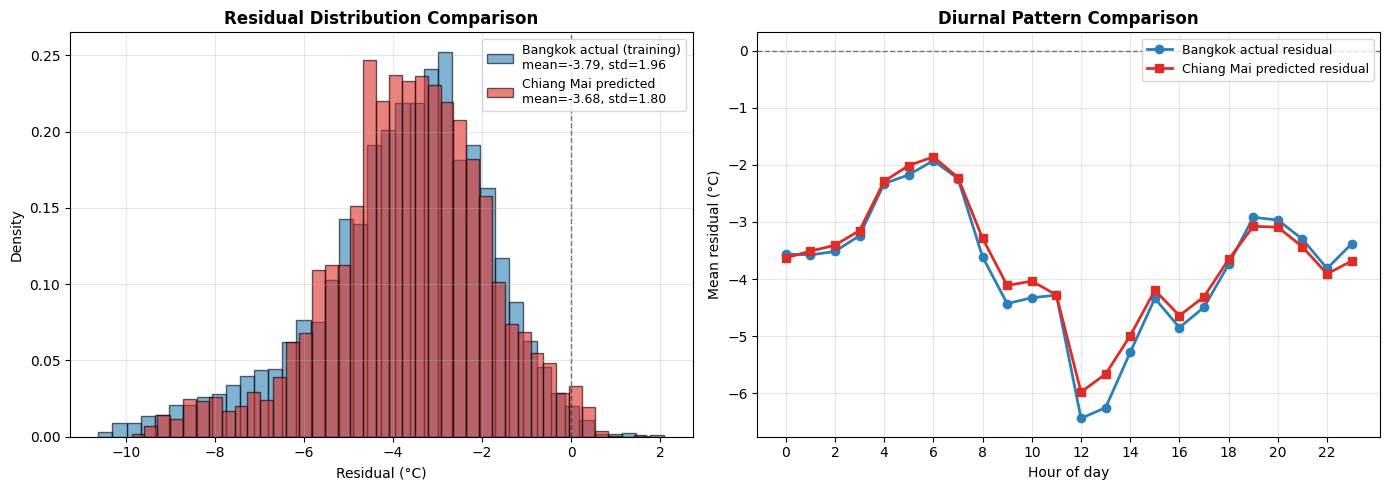


Distribution comparison:
Metric                        Bangkok (actual)    Chiang Mai (predicted)
---------------------------------------------------------------------------
Mean                                    -3.790                    -3.684
Std                                      1.961                     1.802
Min                                    -10.617                    -9.870
Max                                     +2.091                    +1.689


In [ ]:
import matplotlib.pyplot as plt

# Bangkok actual residuals (from training data — what the model learned)
bangkok_residuals = df_train['residual'].values

# Chiang Mai predicted residuals (what the model outputs in a new location)
chiangmai_residuals_pred = predicted_residual_cm

# Distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Histograms overlaid
ax = axes[0]
ax.hist(bangkok_residuals, bins=40, alpha=0.6, label=f'Bangkok actual (training)\nmean={bangkok_residuals.mean():+.2f}, std={bangkok_residuals.std():.2f}',
        color='#2c7fb8', edgecolor='black', density=True)
ax.hist(chiangmai_residuals_pred, bins=40, alpha=0.6, label=f'Chiang Mai predicted\nmean={chiangmai_residuals_pred.mean():+.2f}, std={chiangmai_residuals_pred.std():.2f}',
        color='#de2d26', edgecolor='black', density=True)
ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Residual (°C)')
ax.set_ylabel('Density')
ax.set_title('Residual Distribution Comparison', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: Diurnal pattern of predicted residuals
ax = axes[1]
df_train_with_hour = df_train.copy()
df_train_with_hour['hour'] = df_train_with_hour['timestamp'].dt.hour
bk_by_hour = df_train_with_hour.groupby('hour')['residual'].mean()

df_om_chiangmai_long['hour'] = df_om_chiangmai_long['timestamp'].dt.hour
cm_by_hour = df_om_chiangmai_long.groupby('hour')['predicted_residual'].mean()

ax.plot(bk_by_hour.index, bk_by_hour.values, marker='o',
        color='#2c7fb8', label='Bangkok actual residual', linewidth=2)
ax.plot(cm_by_hour.index, cm_by_hour.values, marker='s',
        color='#de2d26', label='Chiang Mai predicted residual', linewidth=2)
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean residual (°C)')
ax.set_title('Diurnal Pattern Comparison', fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Numerical comparison
print("\nDistribution comparison:")
print(f"{'Metric':<25s} {'Bangkok (actual)':>20s} {'Chiang Mai (predicted)':>25s}")
print("-" * 75)
print(f"{'Mean':<25s} {bangkok_residuals.mean():>+20.3f} {chiangmai_residuals_pred.mean():>+25.3f}")
print(f"{'Std':<25s} {bangkok_residuals.std():>20.3f} {chiangmai_residuals_pred.std():>25.3f}")
print(f"{'Min':<25s} {bangkok_residuals.min():>+20.3f} {chiangmai_residuals_pred.min():>+25.3f}")
print(f"{'Max':<25s} {bangkok_residuals.max():>+20.3f} {chiangmai_residuals_pred.max():>+25.3f}")

FEATURE DISTRIBUTION CHECK — Bangkok train vs Chiang Mai input

om_temp:
  Bangkok train:    range [24.05, 39.95]   mean=31.16   std=3.15
  Chiang Mai input: range [21.90, 39.95]   mean=31.01   std=3.13
  Out-of-range Chiang Mai values: 0.6%

om_humidity:
  Bangkok train:    range [15.22, 93.62]   mean=63.68   std=17.53
  Chiang Mai input: range [15.22, 100.00]   mean=63.18   std=16.95
  Out-of-range Chiang Mai values: 0.3%


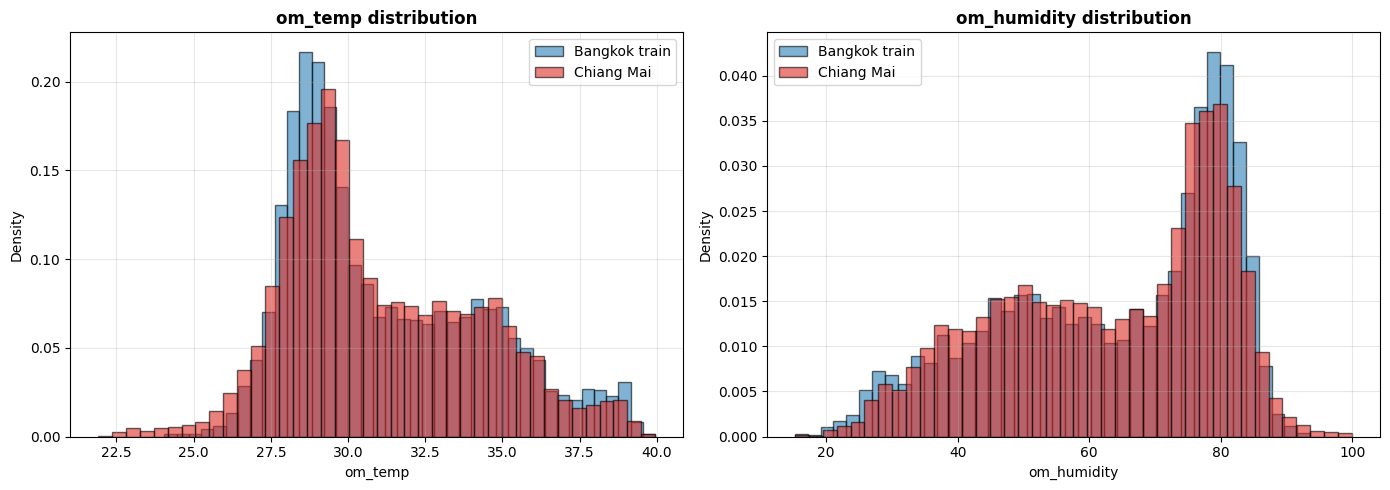

In [ ]:
# Check if Chiang Mai features are within Bangkok training distribution
print("="*70)
print("FEATURE DISTRIBUTION CHECK — Bangkok train vs Chiang Mai input")
print("="*70)

for feat in ['om_temp', 'om_humidity']:
    bk_min, bk_max = df_train[feat].min(), df_train[feat].max()
    bk_mean, bk_std = df_train[feat].mean(), df_train[feat].std()
    cm_min, cm_max = df_om_chiangmai_long[feat].min(), df_om_chiangmai_long[feat].max()
    cm_mean, cm_std = df_om_chiangmai_long[feat].mean(), df_om_chiangmai_long[feat].std()

    # Fraction of Chiang Mai values outside Bangkok training range
    pct_out_of_range = (
        ((df_om_chiangmai_long[feat] < bk_min) | (df_om_chiangmai_long[feat] > bk_max)).mean() * 100
    )

    print(f"\n{feat}:")
    print(f"  Bangkok train:    range [{bk_min:.2f}, {bk_max:.2f}]   mean={bk_mean:.2f}   std={bk_std:.2f}")
    print(f"  Chiang Mai input: range [{cm_min:.2f}, {cm_max:.2f}]   mean={cm_mean:.2f}   std={cm_std:.2f}")
    print(f"  Out-of-range Chiang Mai values: {pct_out_of_range:.1f}%")

# Visual feature distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, feat in enumerate(['om_temp', 'om_humidity']):
    ax = axes[i]
    ax.hist(df_train[feat], bins=40, alpha=0.6, label='Bangkok train',
            color='#2c7fb8', density=True, edgecolor='black')
    ax.hist(df_om_chiangmai_long[feat], bins=40, alpha=0.6, label='Chiang Mai',
            color='#de2d26', density=True, edgecolor='black')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.set_title(f'{feat} distribution', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Summary interpretation
print("="*70)
print("SPATIAL GENERALIZATION TEST — INTERPRETATION")
print("="*70)

bk_mean_resid = bangkok_residuals.mean()
bk_std_resid = bangkok_residuals.std()
cm_mean_resid = chiangmai_residuals_pred.mean()
cm_std_resid = chiangmai_residuals_pred.std()

mean_shift = abs(cm_mean_resid - bk_mean_resid)
std_ratio = cm_std_resid / bk_std_resid

print(f"\nBangkok actual residuals:    mean={bk_mean_resid:+.3f}, std={bk_std_resid:.3f}")
print(f"Chiang Mai predicted:        mean={cm_mean_resid:+.3f}, std={cm_std_resid:.3f}")
print(f"\nMean shift:  {mean_shift:.3f}°C")
print(f"Std ratio:   {std_ratio:.2f}x")

print("\nInterpretation:")
if mean_shift < 0.5 and 0.7 <= std_ratio <= 1.3:
    print("  ✓ Distributions are similar.")
    print("    Bangkok model produces sensible predictions in Chiang Mai climate.")
    print("    Suggests partial spatial generalization within Thai climate zones.")
elif mean_shift < 1.0 and 0.5 <= std_ratio <= 2.0:
    print("  ⚡ Mild distribution shift.")
    print("    Model still produces reasonable predictions but with some divergence.")
    print("    Would need ground truth data to confirm accuracy.")
else:
    print("  ⚠ Significant distribution shift.")
    print("    Model may be extrapolating beyond what it learned.")
    print("    Predictions in Chiang Mai should not be trusted without validation.")

print("\nLIMITATION:")
print("  This test cannot validate accuracy — we have no Chiang Mai field sensor data.")
print("  It only verifies whether the model produces plausible outputs in a new climate zone.")
print("  True validation requires sensor deployment at a second farm.")

SPATIAL GENERALIZATION TEST — INTERPRETATION

Bangkok actual residuals:    mean=-3.790, std=1.961
Chiang Mai predicted:        mean=-3.684, std=1.802

Mean shift:  0.106°C
Std ratio:   0.92x

Interpretation:
  ✓ Distributions are similar.
    Bangkok model produces sensible predictions in Chiang Mai climate.
    Suggests partial spatial generalization within Thai climate zones.

LIMITATION:
  This test cannot validate accuracy — we have no Chiang Mai field sensor data.
  It only verifies whether the model produces plausible outputs in a new climate zone.
  True validation requires sensor deployment at a second farm.
